# Worked Example: Snow Hydrology in Southern Ontario

Many studies have shown that rivers and lakes are drying up in late spring and summer, especially in mountain regions. Hence, this project investigates if similar potential effects of climate change on snow hydrology are seen in Southern Ontario, Canada. To start with, we will focus on a single spatial location: Toronto

# PART 1: Single Simulation Analysis

## 1.1 Study Design

Before our analysis, some preliminary decisions must be made. First, since this is a single location analsis, the spatial domain is <b>Toronto</b>. Next, we need to decide the time periods of analysis. For the historical period which is used as a baseline for downscaling, we will chose <b>1980-2020</b>. For the future period, we will use end-of-century period <b>2070-2100</b>. We also need to specify which future scenario we want to study. Here we only look at <b>SSP2-4.5</b>, which is intermediate emissions, but not yet reached net zero by 2100. 

The model we use here is the <b> Canadian Earth System Model version 5 (CanESM5)</b>, which is Earth System Model developed at the Canadian Centre for Climate Modelling and Analysis (CCCma). Later we will perform the multi-model analysis, we will expand the analysis to include more models.

To calculate snow, we specifically examine the <b>snow cover duration</b> and <b>peak snow water equivalent (SWE)</b>. Snow cover duration is defined as the longest stretch of days where snow depth \$\ge$ 1 cm, while Peak SWE is an indicator of total amount of water produced from melting snow. In order to calculate these snow indicate, we need <b>daily surface air temperature</b> and <b>daily precipitation</b> as our input variables and pass the data to a snowpack model.

Lastly, we will extract the temperature and precipitation data from ECCC weather station.

Below is a table summarizing all the variables and survey answers for this project:

<table style="width=80%">
<tr>
<td> Spatial Domain </td>
<td> Toronto </td>
</tr>

<tr>
<td> Historical Period </td>
<td> 1980-2020 </td>
</tr>
    
<tr>
<td> Future Period </td>
<td> 2070-2100 </td>
</tr>
    
<tr>
<td> Future Scenario </td>
<td> SSP2-4.5 </td>
</tr>

<tr>
<td> Climate Indicator </td>
<td> Snow Cover Duration, Peak SWE </td>
</tr>
    
<tr>
<td> Input Variables </td>
<td> Surface Air Temperature, Precipitation </td>
</tr>
    
<tr>
<td> Climate Model Data </td>
<td> CanESM5 </td>
</tr>
    
</table>

## 1.2 Downscaling Dataset

In [202]:
# import necessary packages
import numpy as np
import pandas as pd
import xarray as xr
import dask
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
spkws = dict(projection = ccrs.PlateCarree(), transform = ccrs.PlateCarree())
import ec3
from tqdm import tqdm
import requests
import nc_time_axis
from siphon.catalog import TDSCatalog
from xclim.core.calendar import convert_calendar, percentile_doy
import xclim.indices as xci
from xclim import sdba

# for getting data from the ESGF
from pyesgf.search import SearchConnection
import os
from os import listdir
from os.path import isfile, exists, getsize
os.environ["ESGF_PYCLIENT_NO_FACETS_STAR_WARNING"] = "on"

In [2]:
# Latitutde and longitude coordinates for Toronto
lat_trt = 43.6532
lon_trt = -79.3832 + 360 # model data longitudes go from (0, 360) instead of (-180, 180)

In [3]:
# Time periods for historical (1980-2020) and future periods (2070-2100)
years_hist = range(1980, 2021)
years_future = range(2070, 2101)

### 1.2.1 Station Data

In [9]:
# Search for stations near Toronto
find_stn_results = ec3.find_station(target = (lat_trt, lon_trt), 
                                    period = years_hist,
                                    type = 'daily',
                                    dist = range(25),
                                    detect_recodes = True)
print(find_stn_results)

Note: In addition to the stations found, the following combinations may provide sufficient baseline data.


>> Combination 1 at coordinates 43.63 -79.4 

Station 5085 : TORONTO ISLAND A (1957-2006)
Station 5086 : TORONTO IS A (AUT) (1973-1973)
Station 30247 : TORONTO CITY CENTRE (2006-2014)
Station 48549 : TORONTO CITY CENTRE (2010-2023)


>> Combination 2 at coordinates 43.67 -79.4 

Station 5051 : TORONTO (1840-2017)
Station 31688 : TORONTO CITY (2002-2023)
Station 41863 : TORONTO SOLAR RADIATION (2018-2018)


>> Combination 3 at coordinates 43.68 -79.63 

Station 5097 : TORONTO LESTER B. PEARSON INT'L A (1937-2013)
Station 51459 : TORONTO INTL A (2013-2023)


No results!
None


To focus on Toronto, we use downtown Toronto station (i.e. Combination 2). This means combining data from Station IDs 5051, 31688 and 41863. 

In [5]:
stn_ids_trt = [5051, 31688, 41863]

Below is a function copied and modified from section 3.1 of the guidebook. It includes <code>ec3.get_data</code> function to download the station data, renaming variable names to remove non-standard characters, and converting "Date" column to Datetime objects.

In [10]:
def download_station_data(stn_id, years = range(1992, 2022)):
    """
    Download ECCC observational data at the weather station identified with stn_id,
    re-name the columns to more useful names. Optional: select specific years of data,
    but by default, download all data from 1990--2020.
    """
    # download the data
    df = ec3.get_data(stn_id, 
                      type = 2, #daily mean data
                      years = years, 
                      progress = False)
    
    # dictionary mapping original column names to new ones
    column_name_dict = {'Date/Time': 'time', 
                    'Mean Temp (°C)': 'tas',
                    'Total Precip (mm)' : 'pr',
                    'Latitude (y)': 'lat',
                    'Longitude (x)': 'lon',
                    'Station Name': 'Name'}
    
    df = df.rename(columns = column_name_dict)
    
    # select only the variables we re-named
    df = df[list(column_name_dict.values())]
    
    # set the "Date" column as an index column and convert it from strings to Datetime objects to make selecting times easier
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index("time")
    
    # sort the data in proper chronological order
    df = df.sort_index()
    
    return df

In [12]:
# Iterate through the station ID list and store the results in a dictionary, with keys being the station IDs
df_dict = {} 
for stn_id in stn_ids_trt:
    df_dict[stn_id] = download_station_data(stn_id, years = years_hist)

We will take a look at the first and last timestep so we can check if there is any time overlap between the two records

In [13]:
for stn_id in stn_ids_trt:
    df = df_dict[stn_id].dropna(inplace = False)
    print(stn_id, df.index.min(), df.index.max())

5051 1980-01-01 00:00:00 2003-06-30 00:00:00
31688 2002-06-04 00:00:00 2020-12-31 00:00:00
41863 NaT NaT


We will disregard station 41863 since it has no actual data. However, records from Station ID 5051 overlaps with Station ID 31688 by almost a year. To visualize the problem, we now plot the temperature and precipitation of the overlapping period between 5051 and 31688.

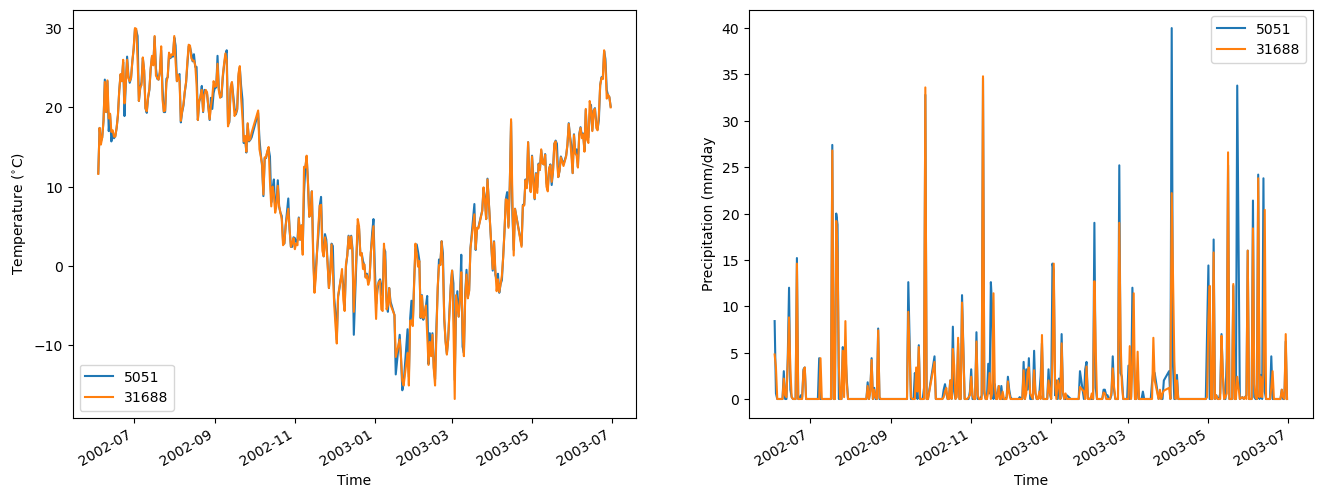

In [121]:
df1 = df_dict[stn_ids_trt[0]].dropna(inplace = False)
df2 = df_dict[stn_ids_trt[1]].dropna(inplace = False)

df1_overlap_period = df1[df1.index.isin(df2.index)]
df2_overlap_period = df2[df2.index.isin(df1.index)]


fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

df1_overlap_period.tas.plot.line(ax = ax[0], label = str(stn_ids_trt[0]))
df2_overlap_period.tas.plot.line(ax = ax[0], label = str(stn_ids_trt[1]))
ax[0].set_ylabel(r'Temperature ($^{\circ}$C)')
ax[0].set_xlabel('Time')
ax[0].legend()

df1_overlap_period.pr.plot.line(ax = ax[1], label = str(stn_ids_trt[0]))
df2_overlap_period.pr.plot.line(ax = ax[1], label = str(stn_ids_trt[1]))
ax[1].set_ylabel('Precipitation (mm/day')
ax[1].set_xlabel('Time')
ax[1].legend()
plt.show()

During the overlapping period, the data from the two stations fairly agree with each other. We will choose the data from Station ID 31688 because it contribues to a greater proportion of the chosen time period.

In [55]:
# Merge the data from different station IDs into a single dataframe
df_obs = df1[df1.index < df2.index.min()].append(df2)

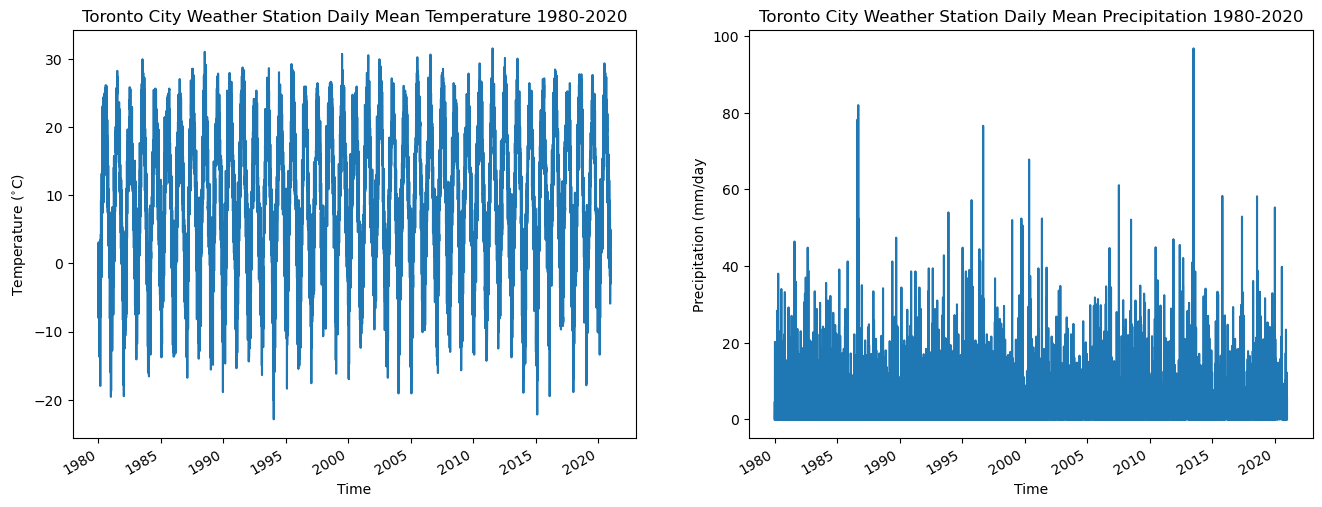

In [123]:
# plot time series of daily mean temperature and precipitation for the whole record

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))
# Temperature
df_obs.tas.plot.line(ax = ax[0])
ax[0].set_title("Toronto City Weather Station Daily Mean Temperature 1980-2020")
ax[0].set_ylabel(r'Temperature ($^{\circ}$C)')
ax[0].set_xlabel('Time')

# Precipitation
df_obs.pr.plot.line(ax = ax[1])
ax[1].set_title("Toronto City Weather Station Daily Mean Precipitation 1980-2020")
ax[1].set_ylabel('Precipitation (mm/day')
ax[1].set_xlabel('Time')
plt.show()

In [218]:
# now convert the dataset to xarray format for easier use with the model data and xclim

# drop lat and lon variables, since we want these to be coordinates in the xr.Dataset
stn_lat = df_obs.lat.values[0] 
stn_lon = df_obs.lon.values[0] + 360 # convert longitude from (-180, 180) to (0, 360) which is the same convention as model data

stn_df = df_obs.drop(['lat', 'lon'], axis = 1)

stn_ds = xr.Dataset.from_dataframe(stn_df)
stn_ds = stn_ds.assign_coords(lat = stn_lat, lon = stn_lon)
stn_ds.tas.attrs['units'] = 'degC'
stn_ds.pr.attrs['units'] = 'mm/day'
stn_ds

<xarray.Dataset>
Dimensions:  (time: 14803)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01 1980-01-02 ... 2020-12-31
    lat      float64 43.67
    lon      float64 280.6
Data variables:
    tas      (time) float64 0.8 0.3 -7.5 -7.6 -4.9 -3.9 ... 1.1 1.7 -2.3 1.7 0.7
    pr       (time) float64 0.0 0.6 0.4 2.2 0.0 4.6 ... 1.0 0.5 3.4 0.0 5.9 0.0
    Name     (time) object 'TORONTO' 'TORONTO' ... 'TORONTO CITY' 'TORONTO CITY'

### 1.2.2 Climate Model Output

After obtaining the station data, the next step is to download the raw climate model output from the Earth System Grid Federation (ESGF) archive. To do so, we first establish a connection to an ESGF node by passing the URL to `pyesgf.search.SearchConnection`.

In [14]:
# Get the data for the raw simulation from ESGF for this same ensemble member.
# this time we'll use the OPeNDAP URL for the ESGF node, so we don't need to download and save the files.
conn = SearchConnection('http://esgf-data.dkrz.de/esg-search', distrib = True)

# The above does not work, try the following:
# LNLL node
#conn = SearchConnection('https://esgf-node.llnl.gov/esg-search', distrib=True)
# UK node
#conn = SearchConnection('https://esgf.ceda.ac.uk/esg-search', distrib= True)
# French node
#conn = SearchConnection('https://esgf-node.ipsl.upmc.fr/esg-search', distrib = True)

We will download the mean daily temperature  (tas) and mean daily precipitation (pr) data. Since there are multiple simulations available for the historical and ssp245 experiments, we will start with the ensemble member r1i1p1f1.

In [15]:
query = conn.new_context(latest = True, # search for most recent versions of the file
                         project = "CMIP6",
                         experiment_id = "historical, ssp245",
                         source_id = "CanESM5",
                         frequency = "day", # daily
                         member_id = "r1i1p1f1",
                         variable_id = "tas, pr")

results = query.search()

len(results)

24

In [16]:
# Make a pd.DataFrame mapping the file names to the URLs.
# sometimes running this cell raises an error, but running it a second time seems to work.
files = []
for i in range(len(results)):
    hit = results[i].file_context().search()
    files += list(map(lambda f: {'filename': f.filename, 
                                 'download_url': f.download_url, 
                                 'opendap_url': f.opendap_url}, hit))
files = pd.DataFrame.from_dict(files)
len(files)

24

In [17]:
# Print out all of the file names to check for duplicates, before we do any downloading

for fname in files['filename'].sort_values(): # print in alphabetical order
    print(fname)

pr_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
pr_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
pr_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
pr_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
pr_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
pr_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
pr_day_CanESM5_ssp245_r1i1p1f1_gn_20150101-21001231.nc
pr_day_CanESM5_ssp245_r1i1p1f1_gn_20150101-21001231.nc
pr_day_CanESM5_ssp245_r1i1p1f1_gn_20150101-21001231.nc
pr_day_CanESM5_ssp245_r1i1p1f1_gn_20150101-21001231.nc
pr_day_CanESM5_ssp245_r1i1p1f1_gn_20150101-21001231.nc
pr_day_CanESM5_ssp245_r1i1p1f1_gn_20150101-21001231.nc
tas_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
tas_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
tas_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
tas_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
tas_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
tas_day_CanESM5_

In [18]:
# filter the DataFrame to drop duplicate filenames
files = files.drop_duplicates('filename')
files

,filename,download_url,opendap_url
0,tas_day_CanESM5_ssp245_r1i1p1f1_gn_20150101-21...,http://esgf3.dkrz.de/thredds/fileServer/cmip6/...,http://esgf3.dkrz.de/thredds/dodsC/cmip6/Scena...
1,pr_day_CanESM5_ssp245_r1i1p1f1_gn_20150101-210...,http://esgf3.dkrz.de/thredds/fileServer/cmip6/...,http://esgf3.dkrz.de/thredds/dodsC/cmip6/Scena...
2,pr_day_CanESM5_historical_r1i1p1f1_gn_18500101...,http://esgf3.dkrz.de/thredds/fileServer/cmip6/...,http://esgf3.dkrz.de/thredds/dodsC/cmip6/CMIP/...
3,tas_day_CanESM5_historical_r1i1p1f1_gn_1850010...,http://esgf3.dkrz.de/thredds/fileServer/cmip6/...,http://esgf3.dkrz.de/thredds/dodsC/cmip6/CMIP/...


In [20]:
# Adapted from: https://stackoverflow.com/a/37573701
def download(url, filename):
    """
    Download a file hosted at <url> and write to <filename>
    """
    print("Downloading ", filename)
    r = requests.get(url, stream=True)
    total_size, block_size = int(r.headers.get('content-length', 0)), 1024
    with open(filename, 'wb') as f:
        for data in tqdm(r.iter_content(block_size),
                         total=total_size//block_size,
                         unit='KiB', unit_scale=True):
            f.write(data)

    if total_size != 0 and os.path.getsize(filename) != total_size:
        print("Downloaded size does not match expected size!\n",
              "FYI, the status code was ", r.status_code)

In [21]:
# create a directory (inside the current working directory) to save the data to
data_directory = "/data/kushner_group/lchan"
if not os.path.exists(data_directory): # only make the directory if it doesn't already exist
    os.mkdir(data_directory)

In [ ]:
# Download the data, one file at a time
for i in range(len(files)):
    url = files['download_url'].loc[i]
    filename = files['filename'].loc[i]
    path_to_write = os.path.join(data_directory, filename)
    
    # only download if the files doesn't already exist. 
    if not os.path.exists(path_to_write): 
        download(url, path_to_write)
    
    # if there is an error downloading a file, you'll need to either delete the file,
    # or change this block of code to call download(url, path_to_write) without 
    # first checking if path_to_write exists,

335kKiB [00:49, 6.84kKiB/s]                                                                                


335kKiB [01:06, 5.06kKiB/s]                                                                                


335kKiB [01:24, 3.97kKiB/s]                                                                                


335kKiB [01:27, 3.85kKiB/s]                                                                                


335kKiB [01:36, 3.46kKiB/s]                                                                                


...

213kKiB [00:43, 4.95kKiB/s]                                                                                


213kKiB [01:00, 3.50kKiB/s]                                                                                


213kKiB [01:15, 2.82kKiB/s]                                                                                


213kKiB [01:03, 3.36kKiB/s]                                                                                


 51%|████████████████████████████████▉                                | 108k/213k [00:41<00:33, 3.12kKiB/s]

In [185]:
# Open the dataset
ds_CanESM5 = xr.open_mfdataset(data_directory + "/*_day_CanESM5*.nc")
ds_CanESM5

<xarray.Dataset>
Dimensions:    (time: 91615, bnds: 2, lat: 64, lon: 128)
Coordinates:
  * time       (time) object 1850-01-01 12:00:00 ... 2100-12-31 12:00:00
  * lat        (lat) float64 -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon        (lon) float64 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
    height     float64 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object dask.array<chunksize=(60225, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 dask.array<chunksize=(60225, 64, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 dask.array<chunksize=(60225, 128, 2), meta=np.ndarray>
    pr         (time, lat, lon) float32 dask.array<chunksize=(60225, 64, 128), meta=np.ndarray>
    tas        (time, lat, lon) float32 dask.array<chunksize=(60225, 64, 128), meta=np.ndarray>
Attributes: (12/53)
    CCCma_model_hash:            Unknown
    CCCma_parent_runid:          p2-pictrl
    CCCma_pycmor_hash:           7c87dd3a822d55650b3c17cd65db0ca251282530
    CCCma_runid:                 p2-his09
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/7d848d11-5f4e-42b3-90c6-9ac0cb4...
    variable_id:                 pr
    variant_label:               r9i1p2f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

In [186]:
print(ds_CanESM5.tas.attrs['units'])
print(ds_CanESM5.pr.attrs['units'])

K
kg m-2 s-1


After downloading the raw model output, the next step is to convert the units to the ones used by the station data and drop leap days to ensure both datasets use the same calendar.

In [187]:
# Convert unit
ds_CanESM5['tas'] = ds_CanESM5['tas'] - 273.15 #Convert from K to degree Celsius
ds_CanESM5['pr'] = ds_CanESM5['pr'] * 60 * 60 * 24  #Convert from kg/m2/s to mm/day

# update the units in the file as well
ds_CanESM5['tas'].attrs['units'] = 'degC'
ds_CanESM5.pr.attrs['units'] = 'mm/day'

#Convert calendar to no leap
ds_CanESM5 = convert_calendar(ds_CanESM5, "noleap")
stn_ds = convert_calendar(stn_ds, "noleap")

Then, we will interpolate it to the coordinates of our station, and select the time periods for the study. For the historical scenario, we use 1980-2020 which is the same time period as we chose for the station observations. For the future period, we will use end-of-century period, which is 2070-2100.

In [188]:
# Interpolate data to the station coordinates
tas_CanESM5 = ds_CanESM5.tas.interp(lat = stn_lat, lon = stn_lon )
pr_CanESM5 = ds_CanESM5.pr.interp(lat = stn_lat, lon = stn_lon )

# Select time periods
tas_hist_CanESM5raw = tas_CanESM5.sel(time = tas_CanESM5.time.dt.year.isin(years_hist))
tas_future_CanESM5raw = tas_CanESM5.sel(time = tas_CanESM5.time.dt.year.isin(years_future))
pr_hist_CanESM5raw = pr_CanESM5.sel(time = pr_CanESM5.time.dt.year.isin(years_hist))
pr_future_CanESM5raw = pr_CanESM5.sel(time = pr_CanESM5.time.dt.year.isin(years_future))

## 1.3 Check Model Consistency with Observations

To quantify the model bias, we will plot the probability distribution function (PDF) of mean daily temperature and precipitation for both raw model and station data, as well as calculate metrics such as mean and standard deviations. 

The following function calculate the kernel density estimator, mean, and standard deviation.

In [189]:
def pdf(data):
    """Return the kernel density estimator, mean value and standard deviation of data"""
    
    # fit Kernel Density Estimator so we can plot a smooth distribution
    kde = stats.gaussian_kde(data.values)
    # mean values for each dataset
    mean = data.mean('time').compute()
    # stdevs for each dataset
    stdev = data.std('time').compute()
    
    return kde, mean, stdev

In [190]:
# Calculate kde, mean and stdev
#Temperature
tas_hist_CanESM5raw_kde, tas_hist_CanESM5raw_mean, tas_hist_CanESM5raw_stdev = pdf(tas_hist_CanESM5raw) # Raw Historical
tas_obs_kde, tas_obs_mean, tas_obs_stdev = pdf(stn_ds.tas) # Station obs

#Precipitation
pr_hist_CanESM5raw_kde, pr_hist_CanESM5raw_mean, pr_hist_CanESM5raw_stdev = pdf(pr_hist_CanESM5raw) #Raw Historical
pr_obs_kde, pr_obs_mean, pr_obs_stdev = pdf(stn_ds.pr) #Station obs

# range of temperatures and precipitation to plot
temperatures = np.arange(-40, 40)
Precipitations = np.arange(-5, 40)

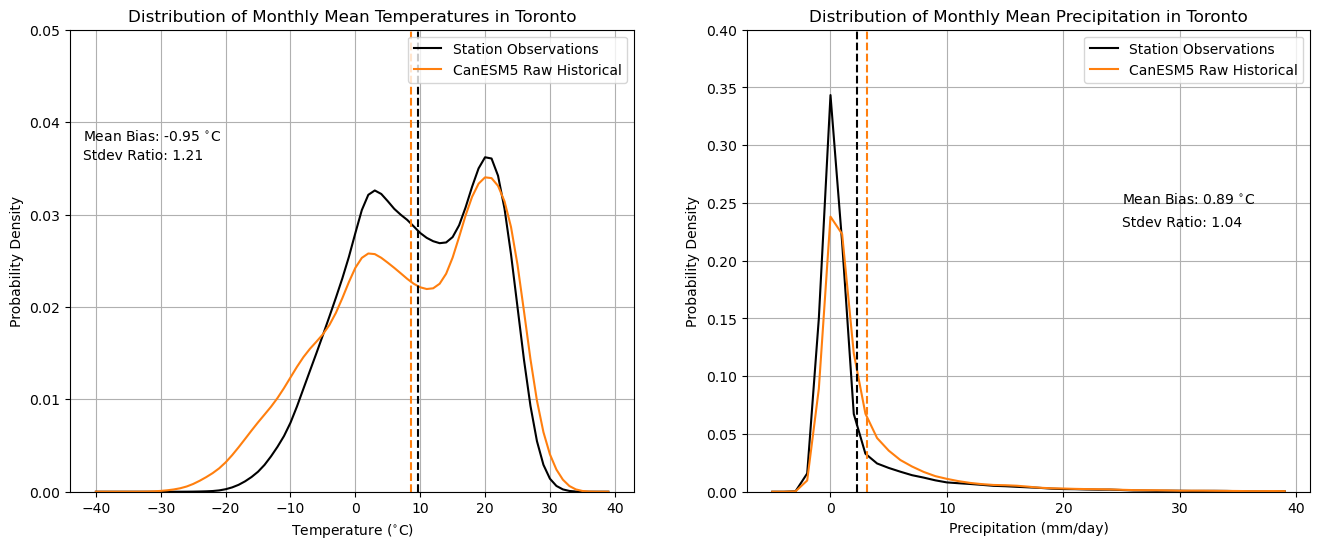

In [197]:
# Plot PDFs
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

# Temperature
ax[0].set_title("Distribution of Monthly Mean Temperatures in Toronto")
ax[0].plot(temperatures, tas_obs_kde(temperatures), label = 'Station Observations', color = 'k')
ax[0].plot(temperatures, tas_hist_CanESM5raw_kde(temperatures), label = 'CanESM5 Raw Historical', color = 'tab:orange')

ax[0].vlines([tas_obs_mean, tas_hist_CanESM5raw_mean], 0, 1, colors = ['k', 'tab:orange'], linestyles = '--')

ax[0].set_ylim(0, 0.05)
ax[0].set_xlabel(r"Temperature ($^{\circ}$C)")

# annotate with mean bias and ratio of stdevs
ax[0].text(-42, 0.038, r'Mean Bias: %.2f $^{\circ}$C' % (tas_hist_CanESM5raw_mean - tas_obs_mean))
ax[0].text(-42, 0.036, r'Stdev Ratio: %.2f' % (tas_hist_CanESM5raw_stdev / tas_obs_stdev))


#Precipitation
ax[1].set_title("Distribution of Monthly Mean Precipitation in Toronto")
ax[1].plot(Precipitations, pr_obs_kde(Precipitations), label = 'Station Observations', color = 'k')
ax[1].plot(Precipitations, pr_hist_CanESM5raw_kde(Precipitations), label = 'CanESM5 Raw Historical', color = 'tab:orange')

ax[1].vlines([pr_obs_mean, pr_hist_CanESM5raw_mean], 0, 1, colors = ['k', 'tab:orange'], linestyles = '--')

ax[1].set_ylim(0, 0.4)
ax[1].set_xlabel("Precipitation (mm/day)")

# annotate with mean bias and ratio of stdevs
ax[1].text(25, 0.25, r'Mean Bias: %.2f $^{\circ}$C' % (pr_hist_CanESM5raw_mean - pr_obs_mean))
ax[1].text(25, 0.23, r'Stdev Ratio: %.2f' % (pr_hist_CanESM5raw_stdev / pr_obs_stdev))

for ax in ax:
    ax.set_ylabel("Probability Density")
    ax.legend(loc = 'upper right')
    ax.grid()
    
plt.show()

In the temperature PDF, the raw model data for Toronto is biased low and has too high of a standard deviation compared to the station observation. One interesting feature of this graph is that the distributions are bimodel. The peak at a lower temperature is for cold seasons while the other peak is for warm seasons. In the precipitation PDF, the model underestimates the amount of precipitation, but the peak is much smaller than the observation.

Since seasonal cycle occurs at this location, let's quantify the monthly bias by comparing the monthly climatologies for both dataset.

In [192]:
def climatology(data, type = "month"):
    """Return climatology and standard deviation of data. Type can be 'month' for monthly climatology (default) or 'day' for daily climatolog."""
    if type == "month":
        clim = data.groupby('time.month').mean('time').compute()
        std = data.groupby('time.month').std('time').compute()
    elif type == "day":
        clim = data.groupby('time.dayofyear').mean('time').compute()
        std = data.groupby('time.dayofyear').std('time').compute()
    
    return clim, std

In [193]:
# calculate monthly climatologies
# Temperature
tas_obs_monthlyclim, tas_obs_monthlyclim_std = climatology(stn_ds.tas) # Station
tas_hist_CanESM5raw_monthlyclim, tas_hist_CanESM5raw_monthlyclim_std = climatology(tas_hist_CanESM5raw) # Raw historical

#Precipitation
pr_obs_monthlyclim, pr_obs_monthlyclim_std = climatology(stn_ds.pr) # Station
pr_hist_CanESM5raw_monthlyclim, pr_hist_CanESM5raw_monthlyclim_std = climatology(pr_hist_CanESM5raw) # Raw historical

months = tas_obs_monthlyclim.month.values 

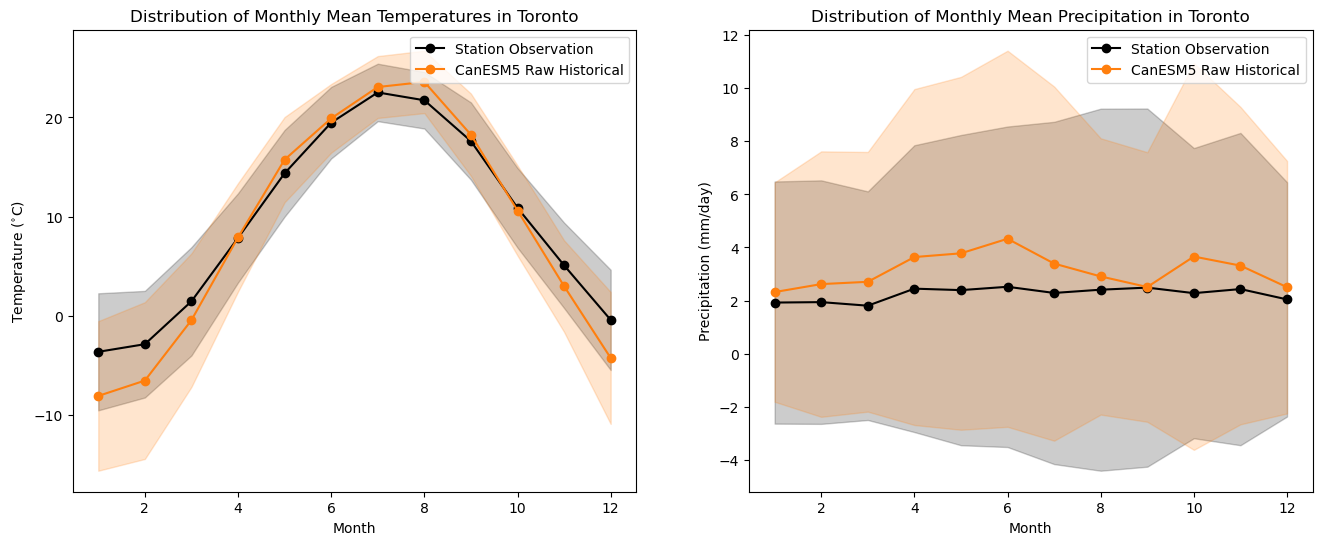

In [198]:
# plot daily climatologies for historical simulation and obs
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

# Temperature
# monthly climatologies as 1D curves
axes[0].plot(months, tas_obs_monthlyclim, label = 'Station Observation', color = 'k', marker = 'o')
axes[0].plot(months, tas_hist_CanESM5raw_monthlyclim, label = 'CanESM5 Raw Historical', color = 'tab:orange', marker = 'o')
#tas_obs_monthlyclim.plot.line(ax = axes[0], label = "Station Observation", color = 'k')
#tas_hist_raw_monthlyclim.plot.line(ax = axes[0], label = "CanESM5 Raw Historical", color = 'tab:orange')

# 1 sigma shading
# observation
axes[0].fill_between(tas_obs_monthlyclim.month,
                tas_obs_monthlyclim - tas_obs_monthlyclim_std, 
                tas_obs_monthlyclim + tas_obs_monthlyclim_std,
                alpha = 0.2, color = 'k')
# raw historical
axes[0].fill_between(tas_hist_CanESM5raw_monthlyclim.month, 
                tas_hist_CanESM5raw_monthlyclim - tas_hist_CanESM5raw_monthlyclim_std, 
                tas_hist_CanESM5raw_monthlyclim  + tas_hist_CanESM5raw_monthlyclim_std,
                alpha = 0.2, color = 'tab:orange')

axes[0].set_title("Distribution of Monthly Mean Temperatures in Toronto")
axes[0].set_ylabel(r"Temperature ($^{\circ}$C)")

# Precipitation
# monthly climatologies as 1D curves
axes[1].plot(months, pr_obs_monthlyclim, label = 'Station Observation', color = 'k', marker = 'o')
axes[1].plot(months, pr_hist_CanESM5raw_monthlyclim, label = 'CanESM5 Raw Historical', color = 'tab:orange', marker = 'o')
#tas_obs_monthlyclim.plot.line(ax = axes[0], label = "Station Observation", color = 'k')
#tas_hist_raw_monthlyclim.plot.line(ax = axes[0], label = "CanESM5 Raw Historical", color = 'tab:orange')

# 1 sigma shading
# observation
axes[1].fill_between(pr_obs_monthlyclim.month,
                     pr_obs_monthlyclim - pr_obs_monthlyclim_std, 
                     pr_obs_monthlyclim + pr_obs_monthlyclim_std,
                     alpha = 0.2, color = 'k')

# raw historical
axes[1].fill_between(pr_hist_CanESM5raw_monthlyclim.month, 
                     pr_hist_CanESM5raw_monthlyclim - pr_hist_CanESM5raw_monthlyclim_std, 
                     pr_hist_CanESM5raw_monthlyclim  + pr_hist_CanESM5raw_monthlyclim_std,
                     alpha = 0.2, color = 'tab:orange')
axes[1].set_title("Distribution of Monthly Mean Precipitation in Toronto")
axes[1].set_ylabel("Precipitation (mm/day)")

for ax in axes:
    ax.set_xlabel('Month')
    ax.legend(loc = 'upper right')

plt.show()

The raw model predicts overly cold winters and slight warmer summer. This causes the overall negative bias and a larger standard deviation in the temperature PDF. For precipitation, the model predicts more precipitation in almost all months, especially in late spring/ early summer. The inter-month variability is also very large.

## 1.4 Evaluate Climate Change Signal

After establishing the model bias between historical simulation and station observations, we will evaluate the climate change signal of the raw model simulation. To do so, we  will plot monthly climatology of the SSP2-4.5 simulation and compare the results to that of the historical simulation.

In [195]:
# calculate monthly climatologies of SSP2-4.5
tas_future_CanESM5raw_monthlyclim, tas_future_CanESM5raw_monthlyclim_std = climatology(tas_future_CanESM5raw) # Temperature
pr_future_CanESM5raw_monthlyclim, pr_future_CanESM5raw_monthlyclim_std = climatology(pr_future_CanESM5raw) # Precipitation

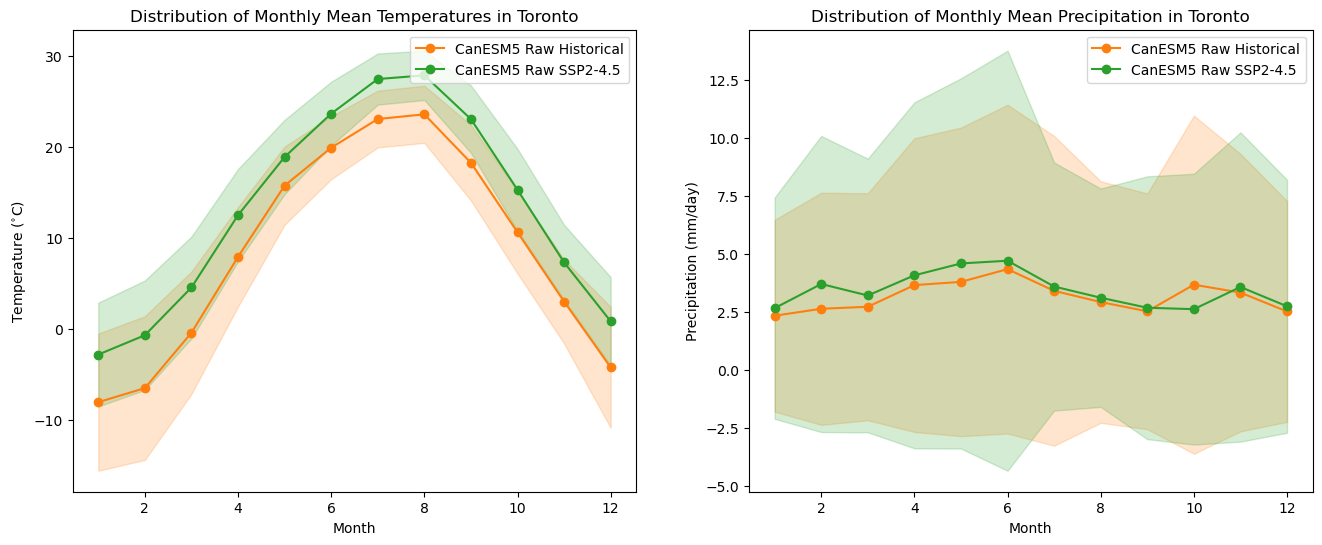

In [196]:
# plot daily climatologies for historical simulation and obs
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

# Temperature
# monthly climatologies as 1D curves
axes[0].plot(months, tas_hist_CanESM5raw_monthlyclim, label = 'CanESM5 Raw Historical', color = 'tab:orange', marker = 'o')
axes[0].plot(months, tas_future_CanESM5raw_monthlyclim, label = 'CanESM5 Raw SSP2-4.5', color = 'tab:green', marker = 'o')

# 1 sigma shading
# raw historical
axes[0].fill_between(tas_hist_CanESM5raw_monthlyclim.month, 
                     tas_hist_CanESM5raw_monthlyclim - tas_hist_CanESM5raw_monthlyclim_std, 
                     tas_hist_CanESM5raw_monthlyclim  + tas_hist_CanESM5raw_monthlyclim_std,
                     alpha = 0.2, color = 'tab:orange')

# Raw Future
axes[0].fill_between(tas_future_CanESM5raw_monthlyclim.month, 
                     tas_future_CanESM5raw_monthlyclim - tas_future_CanESM5raw_monthlyclim_std, 
                     tas_future_CanESM5raw_monthlyclim  + tas_future_CanESM5raw_monthlyclim_std,
                     alpha = 0.2, color = 'tab:green')

axes[0].set_title("Distribution of Monthly Mean Temperatures in Toronto")
axes[0].set_ylabel(r"Temperature ($^{\circ}$C)")

# Precipitation
# monthly climatologies as 1D curves
axes[1].plot(months, pr_hist_CanESM5raw_monthlyclim, label = 'CanESM5 Raw Historical', color = 'tab:orange', marker = 'o')
axes[1].plot(months, pr_future_CanESM5raw_monthlyclim, label = 'CanESM5 Raw SSP2-4.5', color = 'tab:green', marker = 'o')

# 1 sigma shading
# raw historical
axes[1].fill_between(pr_hist_CanESM5raw_monthlyclim.month, 
                     pr_hist_CanESM5raw_monthlyclim - pr_hist_CanESM5raw_monthlyclim_std, 
                     pr_hist_CanESM5raw_monthlyclim  + pr_hist_CanESM5raw_monthlyclim_std,
                     alpha = 0.2, color = 'tab:orange')

# Raw Future
axes[1].fill_between(pr_future_CanESM5raw_monthlyclim.month, 
                     pr_future_CanESM5raw_monthlyclim - pr_future_CanESM5raw_monthlyclim_std, 
                     pr_future_CanESM5raw_monthlyclim  + pr_future_CanESM5raw_monthlyclim_std,
                     alpha = 0.2, color = 'tab:green')

axes[1].set_title("Distribution of Monthly Mean Precipitation in Toronto")
axes[1].set_ylabel("Precipitation (mm/day)")

for ax in axes:
    ax.set_xlabel('Month')
    ax.legend(loc = 'upper right')

plt.show()

We can clearly see that warming will occur in the end-of-century period under SSP2-4.5 scenario. The amount of warming is similar among all months. As for precipitation, in the future there will be slightly more precipitation and a greater variability in the first half of the year. The second half of the year is similar to the historical period except in October.

##  1.5 Apply Statistical Downscaling Method

In the study, we use Quantile Delta Mapping (QDM, <code>cannon_bias_2015</code> and Section 4.2.3.3) as the methods of bia-correction. QDM is chosen because it can correct bias in each quantile of the cumulative distribution, hence preserving both the mean climate change signal and the extreme values. <code>xclim.sdba</code> module has different quantile-mapping (QM) based bias correction, including QDM. Since temperature and precipitation in Toronto have seasonal cycles, to account for seaonally-varying biases, we will group the data by month when performing the bias-correction.

In [236]:
# xclim's QM methods don't allow chunking along the time dimension, so this will re-chunk the data to a single chunk along the time dimension
tas_hist_CanESM5raw = tas_hist_CanESM5raw.chunk(time = -1)
tas_future_CanESM5raw = tas_future_CanESM5raw.chunk(time = -1)
pr_hist_CanESM5raw = pr_hist_CanESM5raw.chunk(time = -1)
pr_future_CanESM5raw = pr_future_CanESM5raw.chunk(time = -1)

In [241]:
# Estimate the quantiles and calculate the adjustment factors
# Temperature
tas_CanESM5qdm = xclim.sdba.adjustment.QuantileDeltaMapping.train(stn_ds.tas, # observational data
                                                                  tas_hist_CanESM5raw, # raw model historical data
                                                                  group = 'time.month') # separate adjustment applied to each month, to correct for bias in seasonal cycle

# Precipitation
pr_CanESM5qdm = xclim.sdba.adjustment.QuantileDeltaMapping.train(stn_ds.pr, # observational data
                                                                 pr_hist_CanESM5raw, # raw model historical data
                                                                 group = 'time.month') 

In [242]:
# Apply the bias correction to the historical and SSP2-4.5 data
tas_hist_CanESM5qdm = tas_CanESM5qdm.adjust(tas_hist_CanESM5raw, interp = 'linear')
tas_future_CanESM5qdm = tas_CanESM5qdm.adjust(tas_future_CanESM5raw, interp = 'linear')
pr_hist_CanESM5qdm = pr_CanESM5qdm.adjust(pr_hist_CanESM5raw, interp = 'linear')
pr_future_CanESM5qdm = pr_CanESM5qdm.adjust(pr_future_CanESM5raw, interp = 'linear')

## 1.6 Validate Bias-Corrected Climate Data

First, let's check the daily climatologies and PDFs of the raw and downscaled simulations. The reason why daily climatologies are plotted here is because we have already grouped the data by month in our bias-correction, so monthly climatologies should match perfectly. But daily climatologies allow us to check if there is any small bias remained.

In [246]:
# calculate monthly climatologies
# Station Obs
tas_obs_dailyclim, tas_obs_dailyclim_std = climatology(stn_ds.tas, type = "day") # Temperature
pr_obs_dailyclim, pr_obs_dailyclim_std = climatology(stn_ds.pr, type = "day") # Precipitation

# Raw CanESM5
tas_hist_CanESM5raw_dailyclim, tas_hist_CanESM5raw_dailyclim_std = climatology(tas_hist_CanESM5raw, type = "day") # Temperature
pr_hist_CanESM5raw_dailyclim, pr_hist_CanESM5raw_dailyclim_std = climatology(pr_hist_CanESM5raw, type = "day") # Precipitation

#Downscaled CanESM5
tas_hist_CanESM5qdm_dailyclim, tas_hist_CanESM5qdm_dailyclim_std = climatology(tas_hist_CanESM5qdm, type = "day") # Temperature
pr_hist_CanESM5qdm_dailyclim, pr_hist_CanESM5qdm_dailyclim_std = climatology(pr_hist_CanESM5qdm, type = "day") # Precipitation

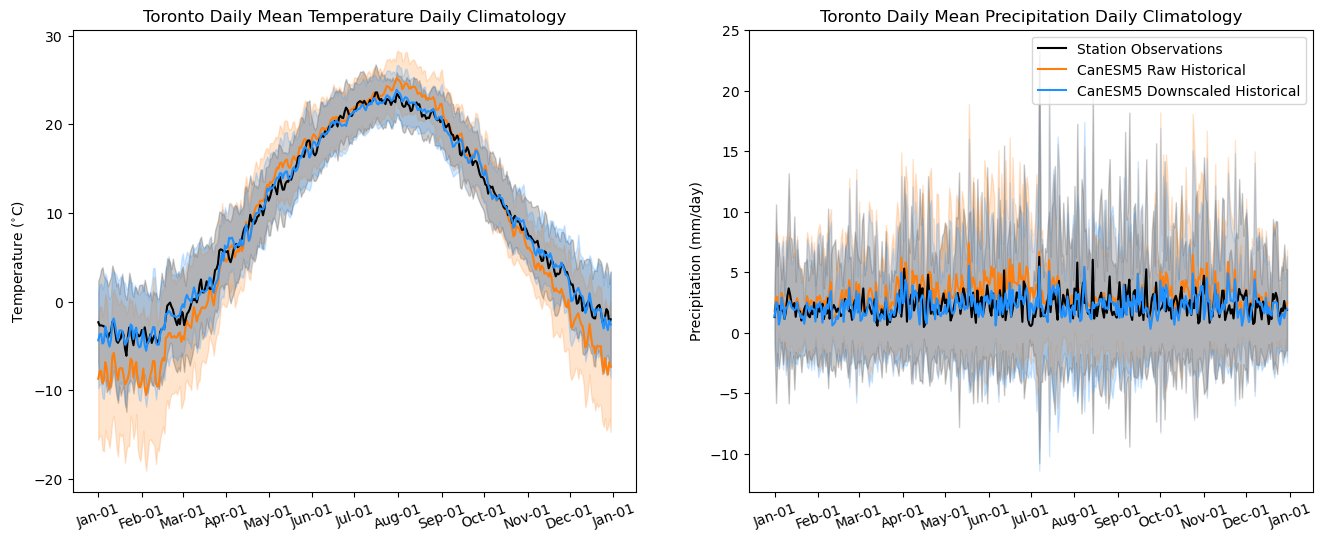

In [252]:
# plot daily climatologies
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

# daily climatologies as 1D curves
#Temperature
tas_hist_CanESM5raw_dailyclim.plot.line(ax = axes[0], label = "CanESM5 Raw Historical", color = 'tab:orange')
tas_obs_dailyclim.plot.line(ax = axes[0], label = "Station Observations", color = 'black')
tas_hist_CanESM5qdm_dailyclim.plot.line(ax = axes[0], label = "CanESM5 Downscaled Historical", color = 'dodgerblue')

# 1 sigma shading
# observation
axes[0].fill_between(tas_obs_dailyclim.dayofyear,
                tas_obs_dailyclim - tas_obs_dailyclim_std, 
                tas_obs_dailyclim + tas_obs_dailyclim_std,
                alpha = 0.2, color = 'k')

# raw CanESM5
axes[0].fill_between(tas_hist_CanESM5raw_dailyclim.dayofyear, 
                tas_hist_CanESM5raw_dailyclim - tas_hist_CanESM5raw_dailyclim_std, 
                tas_hist_CanESM5raw_dailyclim  + tas_hist_CanESM5raw_dailyclim_std,
                alpha = 0.2, color = 'tab:orange')


# Downscaled CanESM5
axes[0].fill_between(tas_hist_CanESM5qdm_dailyclim.dayofyear, 
                     tas_hist_CanESM5qdm_dailyclim - tas_hist_CanESM5qdm_dailyclim_std, 
                     tas_hist_CanESM5qdm_dailyclim  + tas_hist_CanESM5qdm_dailyclim_std,
                     alpha = 0.2, color = 'dodgerblue')

axes[0].set_title("Toronto Daily Mean Temperature Daily Climatology")
axes[0].set_ylabel(r"Temperature ($^{\circ}$C)")


# Precipitation
# monthly climatologies as 1D curves
pr_hist_CanESM5raw_dailyclim.plot.line(ax = axes[1], label = "CanESM5 Raw Historical", color = 'tab:orange')
pr_obs_dailyclim.plot.line(ax = axes[1], label = "Station Observations", color = 'black')
pr_hist_CanESM5qdm_dailyclim.plot.line(ax = axes[1], label = "CanESM5 Downscaled Historical", color = 'dodgerblue')

# 1 sigma shading
# observation
axes[1].fill_between(pr_obs_dailyclim.dayofyear,
                     pr_obs_dailyclim - pr_obs_dailyclim_std, 
                     pr_obs_dailyclim + pr_obs_dailyclim_std,
                     alpha = 0.2, color = 'k')

# raw historical
axes[1].fill_between(pr_hist_CanESM5raw_dailyclim.dayofyear, 
                     pr_hist_CanESM5raw_dailyclim - pr_hist_CanESM5raw_dailyclim_std, 
                     pr_hist_CanESM5raw_dailyclim  + pr_hist_CanESM5raw_dailyclim_std,
                     alpha = 0.2, color = 'tab:orange')

# Downscaled historical
axes[1].fill_between(pr_hist_CanESM5qdm_dailyclim.dayofyear, 
                     pr_hist_CanESM5qdm_dailyclim - pr_hist_CanESM5qdm_dailyclim_std, 
                     pr_hist_CanESM5qdm_dailyclim  + pr_hist_CanESM5qdm_dailyclim_std,
                     alpha = 0.2, color = 'dodgerblue')

axes[1].set_title("Toronto Daily Mean Precipitation Daily Climatology")
axes[1].set_ylabel("Precipitation (mm/day)")

# Set the x axis so that it shows first day of each month
for ax in axes:
    ax.set_xlabel('')
    ax.set_xticks([1,32,61,92,122,153,183,214,245,275,306,336,367])
    ax.set_xticklabels(['Jan-01', 'Feb-01','Mar-01','Apr-01','May-01','Jun-01','Jul-01','Aug-01','Sep-01', 'Oct-01','Nov-01','Dec-01', 'Jan-01'], rotation = 20)

# Reorder the legend
handles, labels = plt.gca().get_legend_handles_labels() # get handles and labels
order = [1,0,2] #specify order of items in legend

#add legend to plot
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order]) 
plt.show()

The daily climatologies really show the effect of downscaling. We can clearly see that after downscaling/bias-correction, the model matches much more closely with the station observations compared to raw model output for both temperature and precipitation. In addition, the uncertainty shading shows greater overlap, suggesting that the interannual variability for each day of the year also have a better match. Next, we wiil look at PDFs and see if there is improvements.

In [253]:
# Calculate kde, mean and stdev of the downscaled historical CanESM5
tas_hist_CanESM5qdm_kde, tas_hist_CanESM5qdm_mean, tas_hist_CanESM5qdm_stdev = pdf(tas_hist_CanESM5qdm) # Temperature
pr_hist_CanESM5qdm_kde, pr_hist_CanESM5qdm_mean, pr_hist_CanESM5qdm_stdev = pdf(pr_hist_CanESM5qdm) # Precipitation

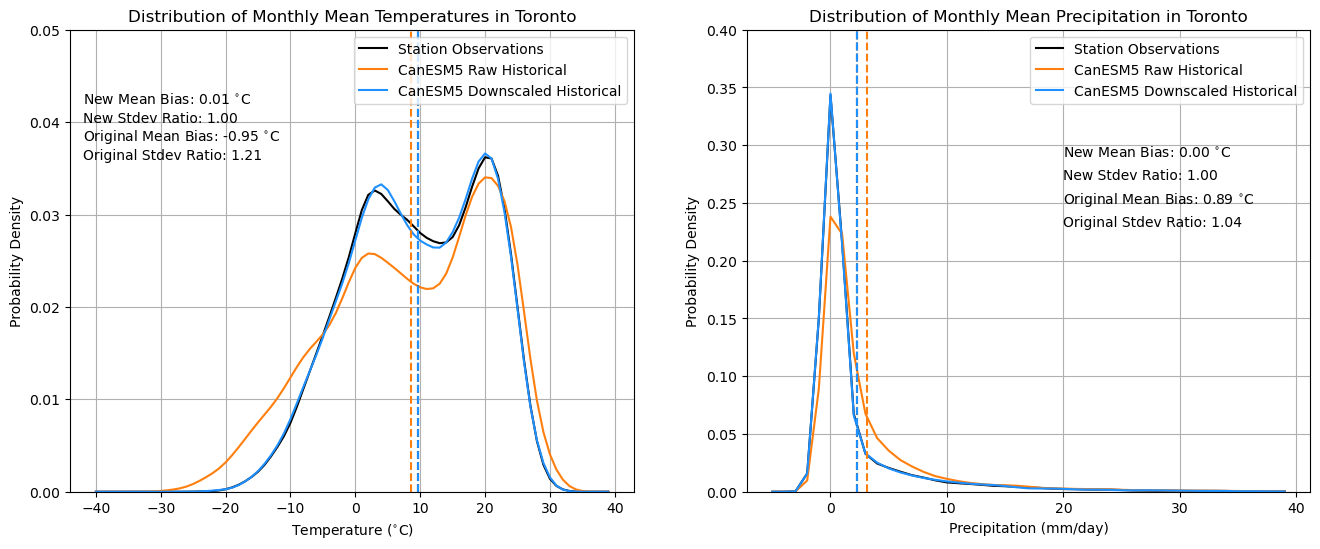

In [256]:
# Plot PDFs
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

# Temperature
ax[0].set_title("Distribution of Monthly Mean Temperatures in Toronto")
ax[0].plot(temperatures, tas_obs_kde(temperatures), label = 'Station Observations', color = 'k')
ax[0].plot(temperatures, tas_hist_CanESM5raw_kde(temperatures), label = 'CanESM5 Raw Historical', color = 'tab:orange')
ax[0].plot(temperatures, tas_hist_CanESM5qdm_kde(temperatures), label = 'CanESM5 Downscaled Historical', color = 'dodgerblue')

ax[0].vlines([tas_obs_mean, tas_hist_CanESM5raw_mean, tas_hist_CanESM5qdm_mean], 0, 1, colors = ['k', 'tab:orange', 'dodgerblue'], linestyles = '--')

ax[0].set_ylim(0, 0.05)
ax[0].set_xlabel(r"Temperature ($^{\circ}$C)")

# annotate with mean bias and ratio of stdevs
ax[0].text(-42, 0.038, r'Original Mean Bias: %.2f $^{\circ}$C' % (tas_hist_CanESM5raw_mean - tas_obs_mean))
ax[0].text(-42, 0.036, r'Original Stdev Ratio: %.2f' % (tas_hist_CanESM5raw_stdev / tas_obs_stdev))
ax[0].text(-42, 0.042, r'New Mean Bias: %.2f $^{\circ}$C' % (tas_hist_CanESM5qdm_mean - tas_obs_mean))
ax[0].text(-42, 0.040, r'New Stdev Ratio: %.2f' % (tas_hist_CanESM5qdm_stdev / tas_obs_stdev))


#Precipitation
ax[1].set_title("Distribution of Monthly Mean Precipitation in Toronto")
ax[1].plot(Precipitations, pr_obs_kde(Precipitations), label = 'Station Observations', color = 'k')
ax[1].plot(Precipitations, pr_hist_CanESM5raw_kde(Precipitations), label = 'CanESM5 Raw Historical', color = 'tab:orange')
ax[1].plot(Precipitations, pr_hist_CanESM5qdm_kde(Precipitations), label = 'CanESM5 Downscaled Historical', color = 'dodgerblue')

ax[1].vlines([pr_obs_mean, pr_hist_CanESM5raw_mean, pr_hist_CanESM5qdm_mean], 0, 1, colors = ['k', 'tab:orange', 'dodgerblue'], linestyles = '--')

ax[1].set_ylim(0, 0.4)
ax[1].set_xlabel("Precipitation (mm/day)")

# annotate with mean bias and ratio of stdevs
ax[1].text(20, 0.25, r'Original Mean Bias: %.2f $^{\circ}$C' % (pr_hist_CanESM5raw_mean - pr_obs_mean))
ax[1].text(20, 0.23, r'Original Stdev Ratio: %.2f' % (pr_hist_CanESM5raw_stdev / pr_obs_stdev))
ax[1].text(20, 0.29, r'New Mean Bias: %.2f $^{\circ}$C' % (pr_hist_CanESM5qdm_mean - pr_obs_mean))
ax[1].text(20, 0.27, r'New Stdev Ratio: %.2f' % (pr_hist_CanESM5qdm_stdev / pr_obs_stdev))

for ax in ax:
    ax.set_ylabel("Probability Density")
    ax.legend(loc = 'upper right')
    ax.grid()
    
plt.show()

Similar to the daily climatologies, the PDFs from downscaled model output nearly overlapped with those from station observations, though the low-temperature peak is still slightly higher. There are almost no mean bias and the standard deviation from downscaled model and station observations are the same. 

## 1.7 Downscaled Projections of our Climate Indicator

To calculate our snow indicator, we need to pass the temperature and precipitation data to Brown Temperature Index Model (B-TIM) (Brasnett 1999), which is a simple snowpack model that generates a daily record of snow depth and snow density. However, there are several steps that need to be done before we can run the B-TIM: 
<ol>
    <li>Each year starts on August 1st and end on July 31st, so we will select 1980-08-01 to 2020-07-31 as historical period and 2700-08-01 to 2100-07-31 as future period </li>
    <li>Save monthly forcing files (e.g. 1980 Aug, 1980 Sept, ...) </li>
</ol>
The code for B-TIM is from taken from <a>https://github.com/aelias-c/B-TIM/tree/aelias-c-update-units</a>

In [265]:
# Select time period
# Station
stn_ds_btim = stn_ds.sel(time=slice("1980-08-01", "2020-07-31")).chunk(time = -1).load()

# Raw Model
tas_hist_CanESM5raw_btim = tas_hist_CanESM5raw.sel(time=slice("1980-08-01", "2020-07-31")).chunk(time = -1).load()
pr_hist_CanESM5raw_btim = pr_hist_CanESM5raw.sel(time=slice("1980-08-01", "2020-07-31")).chunk(time = -1).load()

tas_future_CanESM5raw_btim = tas_future_CanESM5raw.sel(time=slice("2070-08-01", "2100-07-31")).chunk(time = -1).load()
pr_future_CanESM5raw_btim = pr_future_CanESM5raw.sel(time=slice("2070-08-01", "2100-07-31")).chunk(time = -1).load()

# Downscaled Model
tas_hist_CanESM5qdm_btim = tas_hist_CanESM5qdm.sel(time=slice("1980-08-01", "2020-07-31")).chunk(time = -1).load()
pr_hist_CanESM5qdm_btim = pr_hist_CanESM5qdm.sel(time=slice("1980-08-01", "2020-07-31")).chunk(time = -1).load()

tas_future_CanESM5qdm_btim = tas_future_CanESM5qdm.sel(time=slice("2070-08-01", "2100-07-31")).chunk(time = -1).load()
pr_future_CanESM5qdm_btim = pr_future_CanESM5qdm.sel(time=slice("2070-08-01", "2100-07-31")).chunk(time = -1).load()

In [263]:
# Directory for saving the monthly files
btim_directory = "/data/kushner_group/lchan/btim/toronto/input"
if not os.path.exists(btim_directory): # only make the directory if it doesn't already exist
    os.mkdir(btim_directory)

In [267]:
# This function will save monthly forcing files according to the file type
def format_for_btim(data, model = "CanESM5raw", type = "hist", var = "tas", btim_directory = btim_directory):
    """Save monthly forcing files from data.  If type = 'hist', the time period is 1980-08-01 to 2020-07-31; 
    if type = 'future', the time period is 2700-08-01 to 2100-07-31. var can either be tas (surface air temperature) or pr (precipitation). 
    Monthly forcing files will be saved to btim_directory. """
    
    # First, standardize the output file names (e.g. CanESM5raw_t2m_08_1980.nc)
    if var == "tas":
        out_pattern = lambda m,y: model + '_t2m_' + str(m).zfill(2) + '_' + str(y) + '.nc'
    elif var == "pr":
        out_pattern = lambda m,y: model + '_tp_' + str(m).zfill(2) + '_' + str(y) + '.nc'
    
    if type == "hist":
        for y in range(1980, 1981):
            for m in range(8, 13):
                outdata = data.where((data.time.dt.month == m) & (data.time.dt.year == y), drop = True)
                outloc = out_pattern(m, y)
                path_to_write = os.path.join(btim_directory, outloc)
                outdata[[var]].to_netcdf(path_to_write)
                
        for y in range(1981, 2020):
            for m in range(1, 13):
                outdata = data.where((data.time.dt.month == m) & (data.time.dt.year == y), drop = True)
                outloc = out_pattern(m, y)
                path_to_write = os.path.join(btim_directory, outloc)
                outdata[[var]].to_netcdf(path_to_write)
                
        for y in range(2020, 2021):
            for m in range(1, 8):
                outdata = data.where((data.time.dt.month == m) & (data.time.dt.year == y), drop = True)
                outloc = out_pattern(m, y)
                path_to_write = os.path.join(btim_directory, outloc)
                outdata[[var]].to_netcdf(path_to_write)
    
    elif type == "future":
        for y in range(2070, 2071):
            for m in range(8, 13):
                outdata = data.where((data.time.dt.month == m) & (data.time.dt.year == y), drop = True)
                outloc = out_pattern(m, y)
                path_to_write = os.path.join(btim_directory, outloc)
                outdata[[var]].to_netcdf(path_to_write)
                
        for y in range(2071, 2100):
            for m in range(1, 13):
                outdata = data.where((data.time.dt.month == m) & (data.time.dt.year == y), drop = True)
                outloc = out_pattern(m, y)
                path_to_write = os.path.join(btim_directory, outloc)
                outdata[[var]].to_netcdf(path_to_write)
                
        for y in range(2100, 2101):
            for m in range(1, 8):
                outdata = data.where((data.time.dt.month == m) & (data.time.dt.year == y), drop = True)
                outloc = out_pattern(m, y)
                path_to_write = os.path.join(btim_directory, outloc)
                outdata[[var]].to_netcdf(path_to_write)

In [ ]:
# Save monthly files to run the B-TIM

# Station Observation
btim(stn_ds_btim.tas, model = "obs", type = "hist", var = "tas")
btim(stn_ds_btim.pr, model = "obs", type = "hist", var = "pr")

# Raw Model
btim(tas_hist_CanESM5raw_btim, model = "CanESM5raw", type = "hist", var = "tas")
btim(pr_hist_CanESM5raw_btim, model = "CanESM5raw", type = "hist", var = "pr")

btim(tas_future_CanESM5raw_btim, model = "CanESM5raw", type = "future", var = "tas")
btim(pr_future_CanESM5raw_btim, model = "CanESM5raw", type = "future", var = "pr")

# Downscaled Model
btim(tas_hist_CanESM5qdm_btim, model = "CanESM5qdm", type = "hist", var = "tas")
btim(pr_hist_CanESM5qdm_btim, model = "CanESM5qdm", type = "hist", var = "pr")

btim(tas_future_CanESM5qdm_btim, model = "CanESM5qdm", type = "future", var = "tas")
btim(pr_future_CanESM5qdm_btim, model = "CanESM5qdm", type = "future", var = "pr")

After running the B-TIM, we can calculate snow cover duration and peak SWE.

### 1.7.1 Snow Cover Duration

Below are some functions to calculate snow cover duration

In [266]:
def sum_runs(s):
 
    i = 1
    
    for ele in s:
        i += int(ele)
    
    return i

In [275]:
threshold = 1 #cm
month_names_aug = ['Aug', 'Sept', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'March', 'April', 'May', 'June', 'July']

def continuous_snow_cover(years, model='CanESM5raw'):
    """Return the longest stretch of days where snow depth is greater than a threshold. model is a unique name for this experiment/run of the model."""
    
    continuous_snow_cover = np.zeros(len(years))
    inloc = '/data/kushner_group/lchan/btim/toronto/output/'+ model + '/'
    fname = lambda mname,y: inloc + model +'_forced_swe_'+mname+'_'+str(y)+'_'+str(y+1)+'.nc'

    for ny,y in enumerate(years):

        data = xr.open_mfdataset([fname(mname, y) for mname in month_names_aug]) # open the dataset
        
        str1 = ('').join(map(str,np.where(data.snow_depth[0,0,:].values<threshold/100, 0, 1))).split('0') 

        continuous_snow_cover[ny] = np.array([sum_runs(i) for i in str1 if str(1) in i]).max()  # Find the longest duration for each year
        
    return continuous_snow_cover

Now we calculate the snow cover duration for each year

In [277]:
years1 = np.arange(1980, 2020)
years2 = np.arange(2070, 2098)

# Obs
snow_cover_obs = continuous_snow_cover(years1, model = 'obs')

# Raw model
snow_cover_CanESM5raw_hist = continuous_snow_cover(years1, model = 'CanESM5raw') # Historical
snow_cover_CanESM5raw_future = continuous_snow_cover(years2, model = 'CanESM5raw') # Future

# Downscaled model
snow_cover_CanESM5qdm_hist = continuous_snow_cover(years1, model = 'CanESM5qdm') # Historical
snow_cover_CanESM5qdm_future = continuous_snow_cover(years2, model = 'CanESM5qdm') # Future

In [278]:
# Calculate Long-term means
# Obs
snow_cover_obs_mean = snow_cover_obs.mean()
# Raw model
snow_cover_CanESM5raw_hist_mean = snow_cover_CanESM5raw_hist.mean()
snow_cover_CanESM5raw_future_mean = snow_cover_CanESM5raw_future.mean()
# Downscaled model
snow_cover_CanESM5qdm_hist_mean = snow_cover_CanESM5qdm_hist.mean()
snow_cover_CanESM5qdm_future_mean = snow_cover_CanESM5qdm_future.mean()

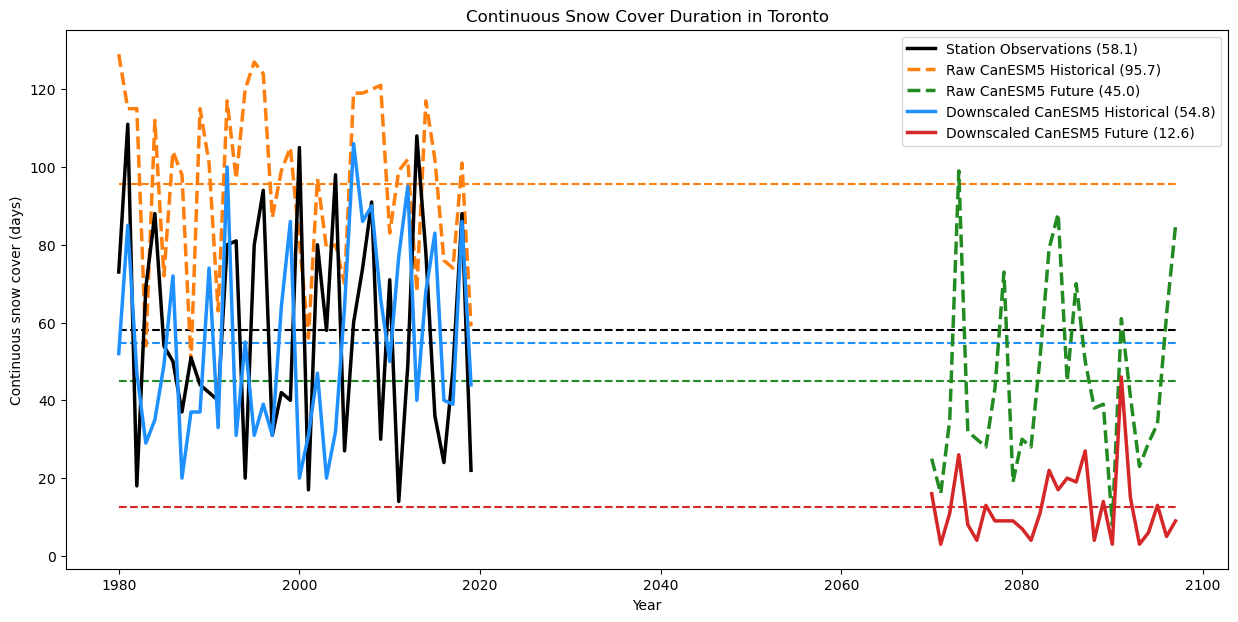

In [288]:
ig = plt.figure(figsize =(15, 7))
ax = fig.add_subplot(111)

#Long-term means
plt.hlines([snow_cover_obs_mean, snow_cover_CanESM5raw_hist_mean, snow_cover_CanESM5raw_future_mean,
            snow_cover_CanESM5qdm_hist_mean, snow_cover_CanESM5qdm_future_mean], 
           years1.min(),
           years2.max(), 
          colors = ['black', 'tab:orange', 'forestgreen', 'dodgerblue', 'tab:red'], linestyles = '--')


plt.plot(years1, snow_cover_CanESM5raw_hist, label = 'Raw CanESM5 Historical (%.1f)' % snow_cover_CanESM5raw_hist_mean, color = 'tab:orange', linestyle = '--', linewidth = 2.5)
plt.plot(years1, snow_cover_obs, label = 'Station Observations (%.1f)' % snow_cover_obs_mean, color = 'black',linewidth = 2.5)
plt.plot(years2, snow_cover_CanESM5raw_future, label = 'Raw CanESM5 Future (%.1f)' % snow_cover_CanESM5raw_future_mean, color = 'forestgreen', linestyle = '--',linewidth = 2.5)
plt.plot(years1, snow_cover_CanESM5qdm_hist, label = 'Downscaled CanESM5 Historical (%.1f)' % snow_cover_CanESM5qdm_hist_mean, color = 'dodgerblue', linewidth = 2.5)
plt.plot(years2, snow_cover_CanESM5qdm_future, label = 'Downscaled CanESM5 Future (%.1f)' % snow_cover_CanESM5qdm_future_mean, color = 'tab:red', linewidth = 2.5)



plt.title('Continuous Snow Cover Duration in Toronto')
plt.ylabel("Continuous snow cover (days)")
plt.xlabel("Year")

plt.xticks()

#get handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

#specify order of items in legend
order = [1,0,2,3,4]

#add legend to plot
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order]) 

The raw model output in the historical period has a much higher snow cover duration than the station observation. This is likely because CanESM5 is biased cold in winter and predicts more precipitation, thus the amount of snow is also overestimated. This graph shows the importance of bias-correction - it brings climate model output closer to the actual data.

When we compare the historical period and future project, we can see that snow cover duration will decrease drastically from about 2 months for the past 40 years to barely 2 weeks by 2100.

## 1.7.2 Peak Snow Water Equivalent (SWE)

In [289]:
def find_peak_swe(years, model = 'CanESM5qdm'):
    """output can either be 'qdm' or 'raw'"""
    
    peak_swe = np.zeros(len(years))
    inloc = '/data/kushner_group/lchan/btim/toronto/output/'+ model + '/'
    fname = lambda mname,y: inloc + model +'_forced_swe_'+mname+'_'+str(y)+'_'+str(y+1)+'.nc'

    for ny,y in enumerate(years):

        data = xr.open_mfdataset([fname(mname, y) for mname in month_names_aug])    
        
        data['peak_SWE'] = data['snow_depth'] * data['density'] #Peak SWE = snow depth*density
        data.peak_SWE.attrs['units'] = 'kg/m2' #Change unit
        peak_swe[ny] = data.peak_SWE.values.max() #Find the max SWE of the year as peak SWE
        
    return peak_swe

In [291]:
# Calculate peak SWE
years1 = np.arange(1980, 2020)
years2 = np.arange(2070, 2100)

# Obs
peak_swe_obs = find_peak_swe(years1, model = 'obs')
# Raw model
peak_swe_CanESM5raw_hist = find_peak_swe(years1, model = 'CanESM5raw')
peak_swe_CanESM5raw_future = find_peak_swe(years2, model = 'CanESM5raw')
# Downscaled model
peak_swe_CanESM5qdm_hist = find_peak_swe(years1, model = 'CanESM5qdm')
peak_swe_CanESM5qdm_future = find_peak_swe(years2, model = 'CanESM5qdm')

In [293]:
# Calculate Long-term means
# Obs
peak_swe_obs_mean = peak_swe_obs.mean()
# Raw model
peak_swe_CanESM5raw_hist_mean = peak_swe_CanESM5raw_hist.mean()
peak_swe_CanESM5raw_future_mean = peak_swe_CanESM5raw_future.mean()
# Downscaled model
peak_swe_CanESM5qdm_hist_mean = peak_swe_CanESM5qdm_hist.mean()
peak_swe_CanESM5qdm_future_mean = peak_swe_CanESM5qdm_future.mean()

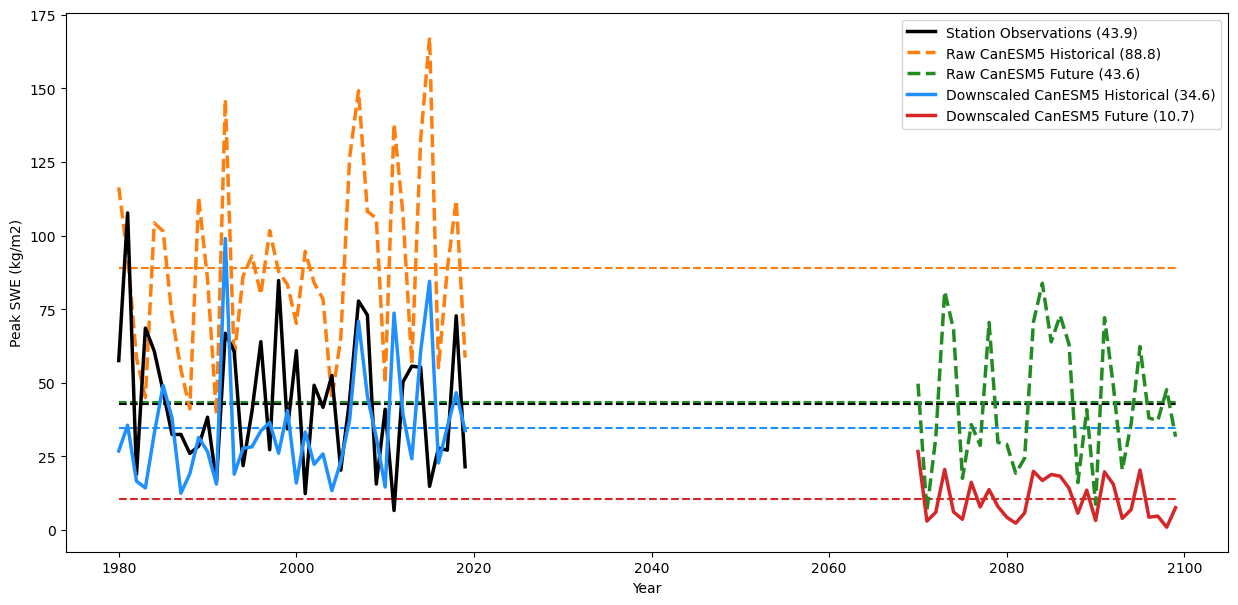

In [296]:
fig = plt.figure(figsize =(15, 7))
ax = fig.add_subplot(111)

#Long-term means
# The long-term mean for station observations is offset by 1 since it is very close to the long-term mean for raw future simulation. 
plt.hlines([peak_swe_obs_mean-1, peak_swe_CanESM5raw_hist_mean, peak_swe_CanESM5raw_future_mean,
            peak_swe_CanESM5qdm_hist_mean, peak_swe_CanESM5qdm_future_mean], 
           years1.min(),
           years2.max(), 
          colors = ['black', 'tab:orange', 'forestgreen', 'dodgerblue', 'tab:red'], linestyles = '--')

plt.plot(years1, peak_swe_CanESM5raw_hist, label = 'Raw CanESM5 Historical (%.1f)' % peak_swe_CanESM5raw_hist_mean, color = 'tab:orange', linestyle = '--', linewidth = 2.5)
plt.plot(years1, peak_swe_obs, label = 'Station Observations (%.1f)' % peak_swe_obs_mean, color = 'black',linewidth = 2.5)
plt.plot(years2, peak_swe_CanESM5raw_future, label = 'Raw CanESM5 Future (%.1f)' % peak_swe_CanESM5raw_future_mean, color = 'forestgreen', linestyle = '--',linewidth = 2.5)
plt.plot(years1, peak_swe_CanESM5qdm_hist, label = 'Downscaled CanESM5 Historical (%.1f)' % peak_swe_CanESM5qdm_hist_mean, color = 'dodgerblue', linewidth = 2.5)
plt.plot(years2, peak_swe_CanESM5qdm_future, label = 'Downscaled CanESM5 Future (%.1f)' % peak_swe_CanESM5qdm_future_mean, color = 'tab:red', linewidth = 2.5)


#plt.title('Duration of Continuous Snow Cover', fontsize = 14)
plt.ylabel("Peak SWE (kg/m2)")
plt.xlabel("Year")

#get handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

#specify order of items in legend
order = [1,0,2,3,4]

#add legend to plot
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order]) 

Although the result is not as significant as snow cover, peak SWE still greatly reduced. It is interesting to note that even after downscaling, there is still bias between downscaled historical data and the station observations. It is likely because of the high peak SWE in early 1980s.

Since different models may have different bias, in the next section we will repeat the above steps and conduct a multi-model analysis.

# PART 2: Multi-model Analysis

Now we continuous with the worked example about snow hydrology in Toronto. This time, we will expand the example and include two other climate models: NorESM2-MM and MPI-ESM1.2-HR. Multi-model analysis allows us to characterize the uncertainty of climate project due to uncertainty in modeling choices. For each model, we will use one ensemble member, r1i1p1f1.

## 2.1 Download Dataset

Just like the previous section, we download the raw climate model output from the Earth System Grid Federation (ESGF) archive

In [346]:
query = conn.new_context(latest = True, # search for most recent versions of the file
                         project ="CMIP6",
                         experiment_id ='historical, ssp245',
                         source_id = 'NorESM2-MM, MPI-ESM1-2-HR',
                         frequency = 'day', # daily
                         member_id ="r1i1p1f1",
                         variable_id = "tas, pr")

results = query.search()

len(results)

42

In [348]:
# Make a pd.DataFrame mapping the file names to the URLs.
# sometimes running this cell raises an error, but running it a second time seems to work.
files = []
for i in range(len(results)):
    hit = results[i].file_context().search()
    files += list(map(lambda f: {'filename': f.filename, 
                                 'download_url': f.download_url, 
                                 'opendap_url': f.opendap_url}, hit))
files = pd.DataFrame.from_dict(files)
len(files)

KeyboardInterrupt: 

In [ ]:
# Print out all of the file names to check for duplicates, before we do any downloading

for fname in files['filename'].sort_values(): # print in alphabetical order
    print(fname)

In [ ]:
# filter the DataFrame to drop duplicate filenames
files = files.drop_duplicates('filename')
files

In [ ]:
# download the data, one file at a time
for i in range(len(files)):
    url = files['download_url'].loc[i]
    filename = files['filename'].loc[i]
    path_to_write = os.path.join(data_directory, filename)
    
    # only download if the files doesn't already exist. 
    if not os.path.exists(path_to_write): 
        download(url, path_to_write)

In [349]:
# Open the NorESM2 and MPI dataset
ds_NorESM2 = xr.open_mfdataset(data_directory + "/*_day_NorESM2-MM*.nc")
ds_MPI = xr.open_mfdataset(data_directory + "/*_day_MPI-ESM1-2-HR*.nc")

In [350]:
ds_NorESM2

<xarray.Dataset>
Dimensions:    (time: 91615, bnds: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 1850-01-01 12:00:00 ... 2100-12-31 12:00:00
  * lat        (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
    height     float64 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object dask.array<chunksize=(3650, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 dask.array<chunksize=(3650, 192, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 dask.array<chunksize=(3650, 288, 2), meta=np.ndarray>
    pr         (time, lat, lon) float32 dask.array<chunksize=(3650, 192, 288), meta=np.ndarray>
    tas        (time, lat, lon) float32 dask.array<chunksize=(3650, 192, 288), meta=np.ndarray>
Attributes: (12/49)
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    branch_method:             Hybrid-restart from year 1200-01-01 of piControl
    branch_time:               0.0
    branch_time_in_child:      0.0
    branch_time_in_parent:     438000.0
    ...                        ...
    title:                     NorESM2-MM output prepared for CMIP6
    variable_id:               pr
    variant_label:             r1i1p1f1
    license:                   CMIP6 model data produced by NCC is licensed u...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/59fecc93-3800-49da-a402-8cf498634437

In [353]:
print(ds_NorESM2.tas.attrs['units'])
print(ds_NorESM2.pr.attrs['units'])

print(ds_MPI.tas.attrs['units'])
print(ds_MPI.pr.attrs['units'])

K
kg m-2 s-1
K
kg m-2 s-1


After downloading the raw model output, the next step is to convert the units to the ones used by the station data and drop leap days to ensure both datasets use the same calendar.

In [355]:
# Convert unit
# NorESM2
ds_NorESM2['tas'] = ds_NorESM2['tas'] - 273.15 # Convert from K to degree Celsius
ds_NorESM2['pr'] = ds_NorESM2['pr'] * 60 * 60 * 24  # Convert from kg/m2/s to mm/day

#MPI
ds_MPI['tas'] = ds_MPI['tas'] - 273.15 # Convert from K to degree Celsius
ds_MPI['pr'] = ds_MPI['pr'] * 60 * 60 * 24  # Convert from kg/m2/s to mm/day

# update the units in the file as well
ds_NorESM2.tas.attrs['units'] = 'degC'
ds_NorESM2.pr.attrs['units'] = 'mm/day'

ds_MPI.tas.attrs['units'] = 'degC'
ds_MPI.pr.attrs['units'] = 'mm/day'

#Convert calendar to no leap
ds_NorESM2 = convert_calendar(ds_NorESM2, "noleap")
ds_MPI = convert_calendar(ds_MPI, "noleap")

Then, we will interpolate it to the coordinates of our station, and select the time periods for the study.

In [357]:
# Interpolate data to the station coordinates
# NorESM2
tas_NorESM2 = ds_NorESM2.tas.interp(lat = stn_lat, lon = stn_lon )
pr_NorESM2 = ds_NorESM2.pr.interp(lat = stn_lat, lon = stn_lon )

# MPI
tas_MPI = ds_MPI.tas.interp(lat = stn_lat, lon = stn_lon )
pr_MPI = ds_MPI.pr.interp(lat = stn_lat, lon = stn_lon )

# Select time periods
# NorESM2
tas_hist_NorESM2raw = tas_NorESM2.sel(time = tas_NorESM2.time.dt.year.isin(years_hist))
tas_future_NorESM2raw = tas_NorESM2.sel(time = tas_NorESM2.time.dt.year.isin(years_future))
pr_hist_NorESM2raw = pr_NorESM2.sel(time = pr_NorESM2.time.dt.year.isin(years_hist))
pr_future_NorESM2raw = pr_NorESM2.sel(time = pr_NorESM2.time.dt.year.isin(years_future))

# MPI
tas_hist_MPIraw = tas_MPI.sel(time = tas_MPI.time.dt.year.isin(years_hist))
tas_future_MPIraw = tas_MPI.sel(time = tas_MPI.time.dt.year.isin(years_future))
pr_hist_MPIraw = pr_MPI.sel(time = pr_MPI.time.dt.year.isin(years_hist))
pr_future_MPIraw = pr_MPI.sel(time = pr_MPI.time.dt.year.isin(years_future))

## 2.2 Check Model Consistency with Observations

We plot the probability distribution function (PDF) of mean daily temperature and precipitation for both raw model and station data. 

In [358]:
# Calculate kde, mean and stdev
#Temperature
tas_hist_NorESM2raw_kde, tas_hist_NorESM2raw_mean, tas_hist_NorESM2raw_stdev = pdf(tas_hist_NorESM2raw) # NorESM2
tas_hist_MPIraw_kde, tas_hist_MPIraw_mean, tas_hist_MPIraw_stdev = pdf(tas_hist_MPIraw) # MPI

#Precipitation
pr_hist_NorESM2raw_kde, pr_hist_NorESM2raw_mean, pr_hist_NorESM2raw_stdev = pdf(pr_hist_NorESM2raw) # NorESM2
pr_hist_MPIraw_kde, pr_hist_MPIraw_mean, pr_hist_MPIraw_stdev = pdf(pr_hist_MPIraw) # MPI

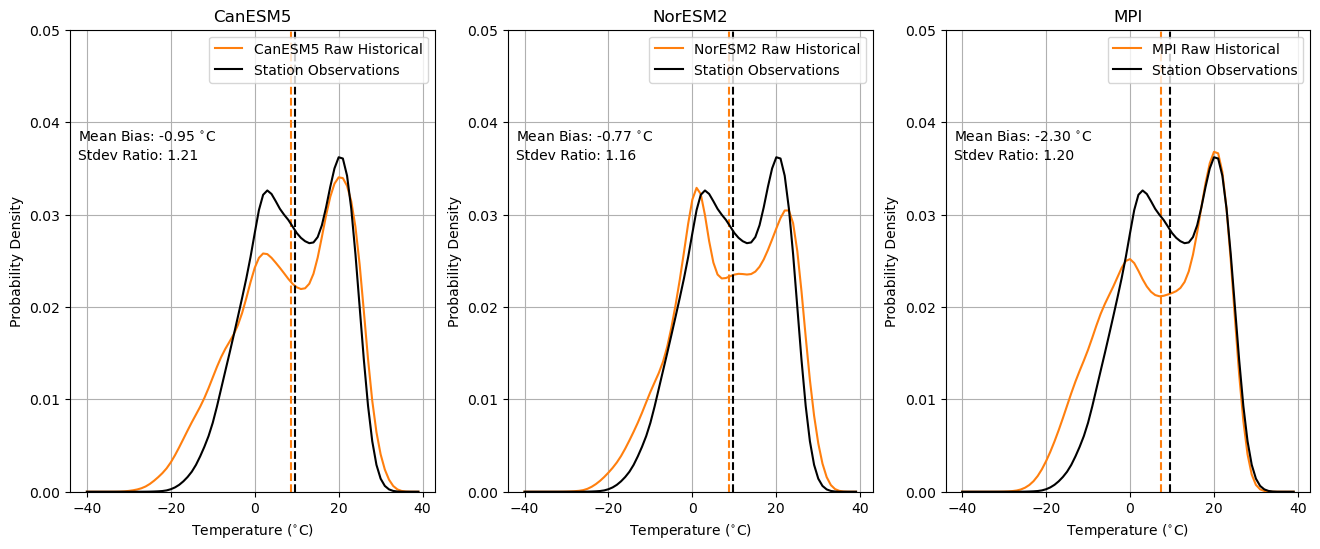

In [364]:
# Plot PDFs. We will plot PDFs for each model side by side for easy comparison

# Temperature
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (16,6))

# CanESM5
ax[0].set_title("CanESM5")
ax[0].plot(temperatures, tas_hist_CanESM5raw_kde(temperatures), label = 'CanESM5 Raw Historical', color = 'tab:orange')

ax[0].vlines([tas_obs_mean, tas_hist_CanESM5raw_mean], 0, 1, colors = ['k', 'tab:orange'], linestyles = '--')

ax[0].set_ylim(0, 0.05)
ax[0].set_xlabel(r"Temperature ($^{\circ}$C)")

# annotate with mean bias and ratio of stdevs
ax[0].text(-42, 0.038, r'Mean Bias: %.2f $^{\circ}$C' % (tas_hist_CanESM5raw_mean - tas_obs_mean))
ax[0].text(-42, 0.036, r'Stdev Ratio: %.2f' % (tas_hist_CanESM5raw_stdev / tas_obs_stdev))


# NorESM2
ax[1].set_title("NorESM2")
ax[1].plot(temperatures, tas_hist_NorESM2raw_kde(temperatures), label = 'NorESM2 Raw Historical', color = 'tab:orange')

ax[1].vlines([tas_obs_mean, tas_hist_NorESM2raw_mean], 0, 1, colors = ['k', 'tab:orange'], linestyles = '--')

ax[1].set_ylim(0, 0.05)
ax[1].set_xlabel(r"Temperature ($^{\circ}$C)")

# annotate with mean bias and ratio of stdevs
ax[1].text(-42, 0.038, r'Mean Bias: %.2f $^{\circ}$C' % (tas_hist_NorESM2raw_mean - tas_obs_mean))
ax[1].text(-42, 0.036, r'Stdev Ratio: %.2f' % (tas_hist_NorESM2raw_stdev / tas_obs_stdev))

# MPI
ax[2].set_title("MPI")
ax[2].plot(temperatures, tas_hist_MPIraw_kde(temperatures), label = 'MPI Raw Historical', color = 'tab:orange')

ax[2].vlines([tas_obs_mean, tas_hist_MPIraw_mean], 0, 1, colors = ['k', 'tab:orange'], linestyles = '--')

ax[2].set_ylim(0, 0.05)
ax[2].set_xlabel(r"Temperature ($^{\circ}$C)")

# annotate with mean bias and ratio of stdevs
ax[2].text(-42, 0.038, r'Mean Bias: %.2f $^{\circ}$C' % (tas_hist_MPIraw_mean - tas_obs_mean))
ax[2].text(-42, 0.036, r'Stdev Ratio: %.2f' % (tas_hist_MPIraw_stdev / tas_obs_stdev))

for ax in ax:
    ax.plot(temperatures, tas_obs_kde(temperatures), label = 'Station Observations', color = 'k')
    ax.set_ylabel("Probability Density")
    ax.legend(loc = 'upper right')
    ax.grid()
    
plt.show()

There is a range of biases across the three models. All three models are biased low and have high standard deviations. In addition, both CanESM5 and MPI have a smaller low-temperature peak while NorESM2 has a smaller high-temperature peak.

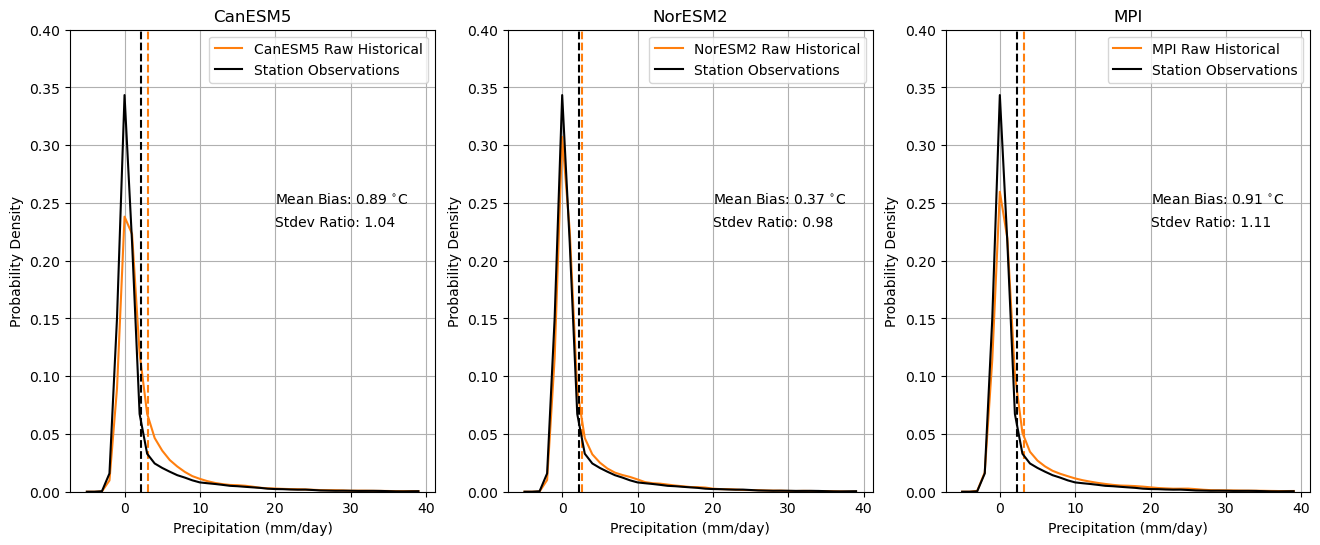

In [369]:
# Plot PDFs. We will plot PDFs for each model side by side for easy comparison

# Precipitation
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (16,6))

# CanESM5
ax[0].set_title("CanESM5")
ax[0].plot(Precipitations, pr_hist_CanESM5raw_kde(Precipitations), label = 'CanESM5 Raw Historical', color = 'tab:orange')
ax[0].vlines([pr_obs_mean, pr_hist_CanESM5raw_mean], 0, 1, colors = ['k', 'tab:orange'], linestyles = '--')

ax[0].set_ylim(0, 0.4)
ax[0].set_xlabel("Precipitation (mm/day)")

# annotate with mean bias and ratio of stdevs
ax[0].text(20, 0.25, r'Mean Bias: %.2f $^{\circ}$C' % (pr_hist_CanESM5raw_mean - pr_obs_mean))
ax[0].text(20, 0.23, r'Stdev Ratio: %.2f' % (pr_hist_CanESM5raw_stdev / pr_obs_stdev))


# NorESM2
ax[1].set_title("NorESM2")
ax[1].plot(Precipitations, pr_hist_NorESM2raw_kde(Precipitations), label = 'NorESM2 Raw Historical', color = 'tab:orange')

ax[1].vlines([pr_obs_mean, pr_hist_NorESM2raw_mean], 0, 1, colors = ['k', 'tab:orange'], linestyles = '--')

ax[1].set_ylim(0, 0.4)
ax[1].set_xlabel("Precipitation (mm/day)")

# annotate with mean bias and ratio of stdevs
ax[1].text(20, 0.25, r'Mean Bias: %.2f $^{\circ}$C' % (pr_hist_NorESM2raw_mean - pr_obs_mean))
ax[1].text(20, 0.23, r'Stdev Ratio: %.2f' % (pr_hist_NorESM2raw_stdev / pr_obs_stdev))

# MPI
ax[2].set_title("MPI")
ax[2].plot(Precipitations, pr_hist_MPIraw_kde(Precipitations), label = 'MPI Raw Historical', color = 'tab:orange')

ax[2].vlines([pr_obs_mean, pr_hist_MPIraw_mean], 0, 1, colors = ['k', 'tab:orange'], linestyles = '--')

ax[2].set_ylim(0, 0.4)
ax[2].set_xlabel("Precipitation (mm/day)")

# annotate with mean bias and ratio of stdevs
ax[2].text(20, 0.25, r'Mean Bias: %.2f $^{\circ}$C' % (pr_hist_MPIraw_mean - pr_obs_mean))
ax[2].text(20, 0.23, r'Stdev Ratio: %.2f' % (pr_hist_MPIraw_stdev / pr_obs_stdev))

for ax in ax:
    ax.plot(Precipitations, pr_obs_kde(Precipitations), label = 'Station Observations', color = 'k')
    ax.set_ylabel("Probability Density")
    ax.legend(loc = 'upper right')
    ax.grid()
    
plt.show()

It seems all three models underestimates the amount of precipitation as the peaks from the raw model output are smaller than the station observations. NorESM2 has the smallest bias compared to the other two models.

We will also look at the monthly bias by comparing the monthly climatologies.

In [370]:
# calculate monthly climatologies
# Temperature
tas_hist_NorESM2raw_monthlyclim, tas_hist_NorESM2raw_monthlyclim_std = climatology(tas_hist_NorESM2raw) # NorESM2
tas_hist_MPIraw_monthlyclim, tas_hist_MPIraw_monthlyclim_std = climatology(tas_hist_MPIraw) # MPI

#Precipitation
pr_hist_NorESM2raw_monthlyclim, pr_hist_NorESM2raw_monthlyclim_std = climatology(pr_hist_NorESM2raw) # NorESM2
pr_hist_MPIraw_monthlyclim, pr_hist_MPIraw_monthlyclim_std = climatology(pr_hist_MPIraw) # MPI

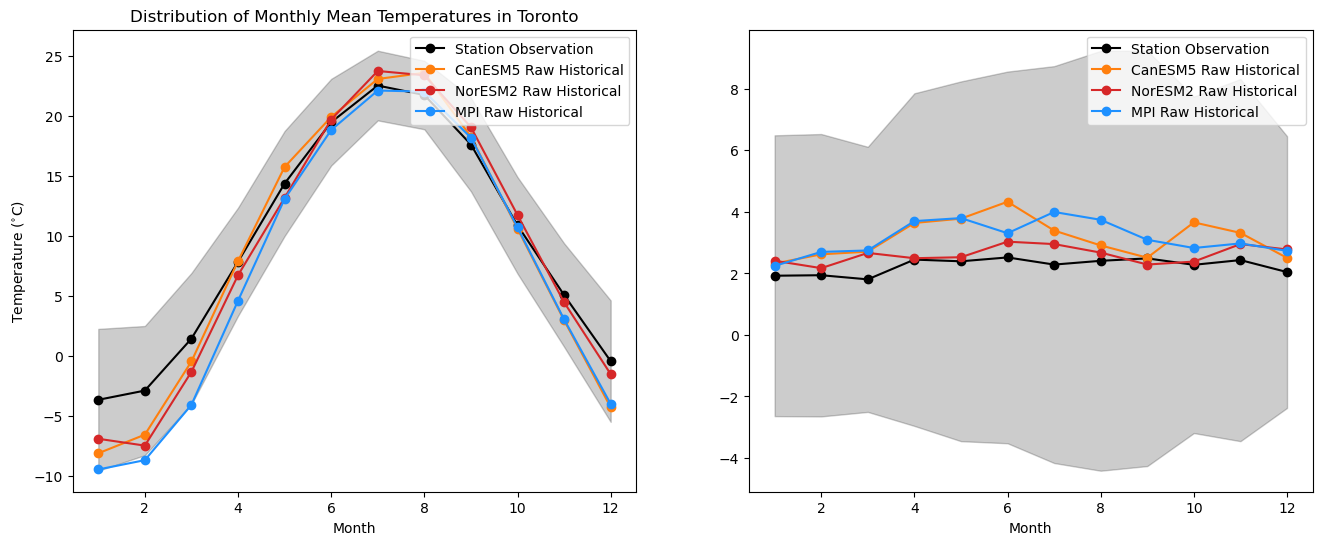

In [382]:
# plot daily climatologies for historical simulation and obs
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

# Temperature
# monthly climatologies as 1D curves
axes[0].plot(months, tas_obs_monthlyclim, label = 'Station Observation', color = 'k', marker = 'o')
axes[0].plot(months, tas_hist_CanESM5raw_monthlyclim, label = 'CanESM5 Raw Historical', color = 'tab:orange', marker = 'o')
axes[0].plot(months, tas_hist_NorESM2raw_monthlyclim, label = 'NorESM2 Raw Historical', color = 'tab:red',marker = 'o')
axes[0].plot(months, tas_hist_MPIraw_monthlyclim, label = 'MPI Raw Historical', color = 'dodgerblue',marker = 'o')

# 1 sigma shading
# observation
axes[0].fill_between(tas_obs_monthlyclim.month,
                tas_obs_monthlyclim - tas_obs_monthlyclim_std, 
                tas_obs_monthlyclim + tas_obs_monthlyclim_std,
                alpha = 0.2, color = 'k')

axes[0].set_title("Distribution of Monthly Mean Temperatures in Toronto")
axes[0].set_ylabel(r"Temperature ($^{\circ}$C)")

# Precipitation
# monthly climatologies as 1D curves
axes[1].plot(months, pr_obs_monthlyclim, label = 'Station Observation', color = 'k', marker = 'o')
axes[1].plot(months, pr_hist_CanESM5raw_monthlyclim, label = 'CanESM5 Raw Historical', color = 'tab:orange', marker = 'o')
axes[1].plot(months, pr_hist_NorESM2raw_monthlyclim, label = 'NorESM2 Raw Historical', color = 'tab:red', marker = 'o')
axes[1].plot(months, pr_hist_MPIraw_monthlyclim, label = 'MPI Raw Historical', color = 'dodgerblue', marker = 'o')

# 1 sigma shading
# observation
axes[1].fill_between(pr_obs_monthlyclim.month,
                     pr_obs_monthlyclim - pr_obs_monthlyclim_std, 
                     pr_obs_monthlyclim + pr_obs_monthlyclim_std,
                     alpha = 0.2, color = 'k')

for ax in axes:
    ax.set_xlabel('Month')
    ax.legend(loc = 'upper right')

plt.show()

CanESM5, NorESM2 and MPI all predict overly cold winters. This causes the overall negative bias and a larger standard deviation in the temperature PDF. For precipitation, models predict more precipitation in almost all months. The inter-month variability is also very large.

## 2.3 Apply Statistical Downscaling Method

Here, we will continue to use Quantile Delta Mapping (QDM) as the methods of bia-correction.

In [373]:
# xclim's QM methods don't allow chunking along the time dimension, so this will re-chunk the data to a single chunk along the time dimension
# NorESM2
tas_hist_NorESM2raw = tas_hist_NorESM2raw.chunk(time = -1)
tas_future_NorESM2raw = tas_future_NorESM2raw.chunk(time = -1)
pr_hist_NorESM2raw = pr_hist_NorESM2raw.chunk(time = -1)
pr_future_NorESM2raw = pr_future_NorESM2raw.chunk(time = -1)

# MPI
tas_hist_MPIraw = tas_hist_MPIraw.chunk(time = -1)
tas_future_MPIraw = tas_future_MPIraw.chunk(time = -1)
pr_hist_MPIraw = pr_hist_MPIraw.chunk(time = -1)
pr_future_MPIraw = pr_future_MPIraw.chunk(time = -1)

In [374]:
# Estimate the quantiles and calculate the adjustment factors
# Temperature
# NorESM2
tas_NorESM2qdm = xclim.sdba.adjustment.QuantileDeltaMapping.train(stn_ds.tas, # observational data
                                                                  tas_hist_NorESM2raw, # raw model historical data
                                                                  group = 'time.month') # separate adjustment applied to each month, to correct for bias in seasonal cycle
# MPI
tas_MPIqdm = xclim.sdba.adjustment.QuantileDeltaMapping.train(stn_ds.tas, # observational data
                                                              tas_hist_MPIraw, # raw model historical data
                                                              group = 'time.month') 

# Precipitation
# NorESM2
pr_NorESM2qdm = xclim.sdba.adjustment.QuantileDeltaMapping.train(stn_ds.pr, # observational data
                                                                 pr_hist_NorESM2raw, # raw model historical data
                                                                 group = 'time.month') 

# MPI
pr_MPIqdm = xclim.sdba.adjustment.QuantileDeltaMapping.train(stn_ds.pr, # observational data
                                                             pr_hist_MPIraw, # raw model historical data
                                                             group = 'time.month') 

In [375]:
# Apply the bias correction to the historical and SSP2-4.5 data
# NorESM2
tas_hist_NorESM2qdm = tas_NorESM2qdm.adjust(tas_hist_NorESM2raw, interp = 'linear')
tas_future_NorESM2qdm = tas_NorESM2qdm.adjust(tas_future_NorESM2raw, interp = 'linear')
pr_hist_NorESM2qdm = pr_NorESM2qdm.adjust(pr_hist_NorESM2raw, interp = 'linear')
pr_future_NorESM2qdm = pr_NorESM2qdm.adjust(pr_future_NorESM2raw, interp = 'linear')

# MPI
tas_hist_MPIqdm = tas_MPIqdm.adjust(tas_hist_MPIraw, interp = 'linear')
tas_future_MPIqdm = tas_MPIqdm.adjust(tas_future_MPIraw, interp = 'linear')
pr_hist_MPIqdm = pr_MPIqdm.adjust(pr_hist_MPIraw, interp = 'linear')
pr_future_MPIqdm = pr_MPIqdm.adjust(pr_future_MPIraw, interp = 'linear')

## 2.4 Validate Bias-Corrected Climate Data

Like before, we will plot the daily climatologies using the downscaled data

In [377]:
# NorESM2
# Raw
tas_hist_NorESM2raw_dailyclim, tas_hist_NorESM2raw_dailyclim_std = climatology(tas_hist_NorESM2raw, type = "day") # Temperature
pr_hist_NorESM2raw_dailyclim, pr_hist_NorESM2raw_dailyclim_std = climatology(pr_hist_NorESM2raw, type = "day") # Precipitation

#Downscaled
tas_hist_NorESM2qdm_dailyclim, tas_hist_NorESM2qdm_dailyclim_std = climatology(tas_hist_NorESM2qdm, type = "day") # Temperature
pr_hist_NorESM2qdm_dailyclim, pr_hist_NorESM2qdm_dailyclim_std = climatology(pr_hist_NorESM2qdm, type = "day") # Precipitation

# MPI
# Raw
tas_hist_MPIraw_dailyclim, tas_hist_MPIraw_dailyclim_std = climatology(tas_hist_MPIraw, type = "day") # Temperature
pr_hist_MPIraw_dailyclim, pr_hist_MPIraw_dailyclim_std = climatology(pr_hist_MPIraw, type = "day") # Precipitation

#Downscaled
tas_hist_MPIqdm_dailyclim, tas_hist_MPIqdm_dailyclim_std = climatology(tas_hist_MPIqdm, type = "day") # Temperature
pr_hist_MPIqdm_dailyclim, pr_hist_MPIqdm_dailyclim_std = climatology(pr_hist_MPIqdm, type = "day") # Precipitation

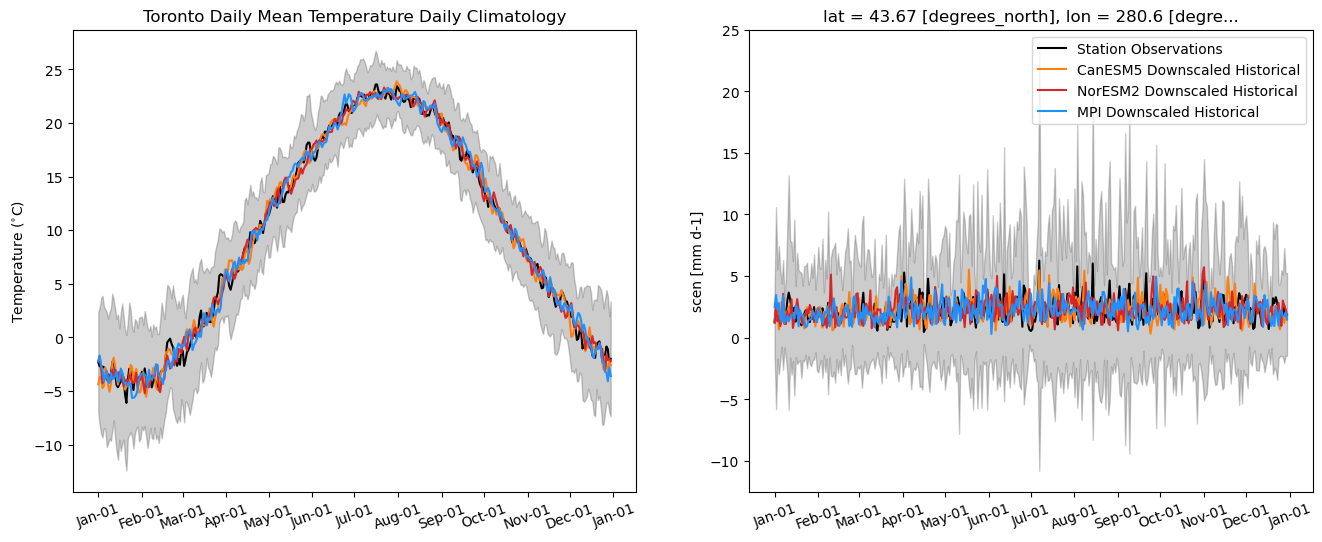

In [381]:
# plot daily climatologies
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

# daily climatologies as 1D curves
#Temperature
tas_obs_dailyclim.plot.line(ax = axes[0], label = "Station Observations", color = 'black')
tas_hist_CanESM5qdm_dailyclim.plot.line(ax = axes[0], label = "CanESM5 Downscaled Historical", color = 'tab:orange')
tas_hist_NorESM2qdm_dailyclim.plot.line(ax = axes[0], label = "NorESM2 Downscaled Historical", color = 'tab:red')
tas_hist_MPIqdm_dailyclim.plot.line(ax = axes[0], label = "MPI Downscaled Historical", color = 'dodgerblue')

# 1 sigma shading
# observation
axes[0].fill_between(tas_obs_dailyclim.dayofyear,
                tas_obs_dailyclim - tas_obs_dailyclim_std, 
                tas_obs_dailyclim + tas_obs_dailyclim_std,
                alpha = 0.2, color = 'k')

axes[0].set_title("Toronto Daily Mean Temperature Daily Climatology")
axes[0].set_ylabel(r"Temperature ($^{\circ}$C)")


# Precipitation
# monthly climatologies as 1D curves
pr_obs_dailyclim.plot.line(ax = axes[1], label = "Station Observations", color = 'black')
pr_hist_CanESM5qdm_dailyclim.plot.line(ax = axes[1], label = "CanESM5 Downscaled Historical", color = 'tab:orange')
pr_hist_NorESM2qdm_dailyclim.plot.line(ax = axes[1], label = "NorESM2 Downscaled Historical", color = 'tab:red')
pr_hist_MPIqdm_dailyclim.plot.line(ax = axes[1], label = "MPI Downscaled Historical", color = 'dodgerblue')

# 1 sigma shading
# observation
axes[1].fill_between(pr_obs_dailyclim.dayofyear,
                     pr_obs_dailyclim - pr_obs_dailyclim_std, 
                     pr_obs_dailyclim + pr_obs_dailyclim_std,
                     alpha = 0.2, color = 'k')

# Set the x axis so that it shows first day of each month
for ax in axes:
    ax.set_xlabel('')
    ax.set_xticks([1,32,61,92,122,153,183,214,245,275,306,336,367])
    ax.set_xticklabels(['Jan-01', 'Feb-01','Mar-01','Apr-01','May-01','Jun-01','Jul-01','Aug-01','Sep-01', 'Oct-01','Nov-01','Dec-01', 'Jan-01'], rotation = 20)

#add legend to plot
plt.legend() 
plt.show()

As expected, after bias-correction the historical data matches the observed seasonal cycle very well, with much less spread than the raw model simulations. Next we'll calculate the snow indicators.

## 2.5 Downscaled Projections of our Climate Indicator

### 2.5.1 Snow Cover Period

### 2.5.2 Peak SWE

# PART 3: Larger Spatial Domain

## 3.1 Study Design

After performing climate impact analysis on a single location. now we will expand our spatial domain to the whole Southern Ontario. All other variables are the same as before.

In [299]:
# bounds of domain
lon = [-85, -73.6]
lat = [41.6, 46.90]

# select 40-year period as historical data
yrmin = 1980
yrmax = 2020
year_range = range(yrmin, yrmax + 1)

## 3.2 Download Dataset

Here we will use a publicly available downscaled gridded data from PCIC. PCIC used observations from NRCAN gridded data from 1950 - 2005 to perform BCCAQv2 downscaling. This example demonstrates that it is acceptable to use an open-source downscaled data if it is available instead of downscaling raw model output by ourselves.

In [300]:
# acquire downscaled data from PAVICS - same as section 4.4
url_pavics = "https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/catalog/datasets/"
url_downscaled = url_pavics + "simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/catalog.xml"
cat_sds = TDSCatalog(url_downscaled)

# open the downscaled gcm dataset and load the data
opendap_urls = [cat_sds.datasets[i].access_urls["OPENDAP"] for i in range(len(cat_sds.datasets))]
datasets_canesm_sds = list(filter(lambda x: 'CanESM' in x, opendap_urls))

datasets_canesm_sds

['https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp585_r9i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp585_r8i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp585_r7i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp585_r6i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp585_r5i1p2f1_gn_1950-2100.ncml',
 'https://pavics.our

This time we will use CanESM5 ensemble member r9i1p2f1

In [304]:
url_sds = datasets_canesm_sds[10] #SSP2-4.5; ensemble member: r9i1p2f1
print(url_sds)
downscaled_ds = xr.open_dataset(url_sds)

# select spatial domain
downscaled_ds = downscaled_ds.sel(lat = slice(*lat), lon = slice(*lon))

# tasmin and tasmax already in DegC, no need to convert units
# pr is in kg/m2/day, which is equivalent to mm/day, so also no need to convert unit for pr

# select GCM data for historical and future periods
downscaled_hist = downscaled_ds.sel(time = downscaled_ds.time.dt.year.isin(range(1980, 2022)))
downscaled_future = downscaled_ds.sel(time = downscaled_ds.time.dt.year.isin(range(2070, 2101)))

https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp245_r9i1p2f1_gn_1950-2100.ncml


To run B-TIM, we need daily mean temperature. However, this dataset only contains daily maximum and daily minimum temperature. Therefore, we will take the average of daily maximum and daily minimum. Since the dataset is too large, we can only calculate the mean after subsetting the dataset into historical and future periods

In [305]:
downscaled_hist['tas'] = (downscaled_hist['tasmin'] + downscaled_hist['tasmax'])/2
downscaled_hist.tas.attrs['units'] = 'DegC'

downscaled_future['tas'] = (downscaled_future['tasmin'] + downscaled_future['tasmax'])/2
downscaled_future.tas.attrs['units'] = 'DegC'

We will also download the raw simulation for the same ensemble member using OPENDAP URL for the ESGF node.

In [306]:
query = conn.new_context(latest = True, # search for most recent versions of the file
                         project="CMIP6",
                         experiment_id='historical, ssp245',
                         source_id = "CanESM5",
                         frequency = 'day', # daily
                         member_id="r9i1p2f1", # different ensemble member as before
                         variable_id = "tas, pr")

results = query.search()

len(results)

18

In [307]:
# Make a pd.DataFrame mapping the file names to the URLs.
# sometimes running this cell raises an error, but running it a second time seems to work.
files = []
for i in range(len(results)):
    hit = results[i].file_context().search()
    files += list(map(lambda f: {'filename': f.filename, 
                                 'download_url': f.download_url, 
                                 'opendap_url': f.opendap_url}, hit))
files = pd.DataFrame.from_dict(files)
len(files)

18

In [308]:
# Print out all of the file names to check for duplicates, before we do any downloading

for fname in files['filename'].sort_values(): # print in alphabetical order
    print(fname)

pr_day_CanESM5_historical_r9i1p2f1_gn_18500101-20141231.nc
pr_day_CanESM5_historical_r9i1p2f1_gn_18500101-20141231.nc
pr_day_CanESM5_historical_r9i1p2f1_gn_18500101-20141231.nc
pr_day_CanESM5_historical_r9i1p2f1_gn_18500101-20141231.nc
pr_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-21001231.nc
pr_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-21001231.nc
pr_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-21001231.nc
pr_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-21001231.nc
pr_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-21001231.nc
tas_day_CanESM5_historical_r9i1p2f1_gn_18500101-20141231.nc
tas_day_CanESM5_historical_r9i1p2f1_gn_18500101-20141231.nc
tas_day_CanESM5_historical_r9i1p2f1_gn_18500101-20141231.nc
tas_day_CanESM5_historical_r9i1p2f1_gn_18500101-20141231.nc
tas_day_CanESM5_historical_r9i1p2f1_gn_18500101-20141231.nc
tas_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-21001231.nc
tas_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-21001231.nc
tas_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-21001231.nc
tas_day_CanESM5_ssp24

In [309]:
# filter the DataFrame to drop duplicate filenames
files = files.drop_duplicates('filename')
files

,filename,download_url,opendap_url
0,tas_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-21...,http://esgf3.dkrz.de/thredds/fileServer/cmip6/...,http://esgf3.dkrz.de/thredds/dodsC/cmip6/Scena...
1,pr_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-210...,http://esgf3.dkrz.de/thredds/fileServer/cmip6/...,http://esgf3.dkrz.de/thredds/dodsC/cmip6/Scena...
2,pr_day_CanESM5_historical_r9i1p2f1_gn_18500101...,http://esgf3.dkrz.de/thredds/fileServer/cmip6/...,http://esgf3.dkrz.de/thredds/dodsC/cmip6/CMIP/...
3,tas_day_CanESM5_historical_r9i1p2f1_gn_1850010...,http://esgf3.dkrz.de/thredds/fileServer/cmip6/...,http://esgf3.dkrz.de/thredds/dodsC/cmip6/CMIP/...


In [310]:
# download the data, one file at a time
for i in range(len(files)):
    url = files['download_url'].loc[i]
    filename = files['filename'].loc[i]
    path_to_write = os.path.join(data_directory, filename)
    
    # only download if the files doesn't already exist. 
    if not os.path.exists(path_to_write): 
        download(url, path_to_write)

In [324]:
# first open the CanESM5 data, all files at once - open_mfdataset will automatically concatenate them in time
raw_CanESM5 = xr.open_mfdataset(data_directory + "/*_day_CanESM5*_r9i1p2f1*.nc")

# Convert unit
raw_CanESM5['tas'] = raw_CanESM5['tas'] - 273.15 #Convert to degree Celsius
# update the units in the file as well
raw_CanESM5['tas'].attrs['units'] = 'degC'

raw_CanESM5['pr'] = raw_CanESM5['pr'] * 60 * 60 * 24  #Convert from kg m-2 s-1 to mm/day
raw_CanESM5.pr.attrs['units'] = 'mm/day'

# get lons bounds on [0, 360] scal
lons360 = [l + 360 for l in lon]
raw_hist = raw_CanESM5.sel(lat = slice(*lat), lon = slice(*lons360), 
                        time = raw_CanESM5.time.dt.year.isin(range(1980, 2021)))

raw_future = raw_CanESM5.sel(lat = slice(*lat), lon = slice(*lons360), 
                        time = raw_CanESM5.time.dt.year.isin(range(2070, 2101)))

# convert back to [-180, 180] to match sds data
raw_hist = raw_hist.assign_coords(lon = raw_hist.lon - 360)
raw_future = raw_future.assign_coords(lon = raw_future.lon - 360)

## 3.3 Exploratory Analysis

Since we do not need to produce our downscaled data, we will only compare the climate change signal between raw and downscaled model output. Let's start with the temperature data.

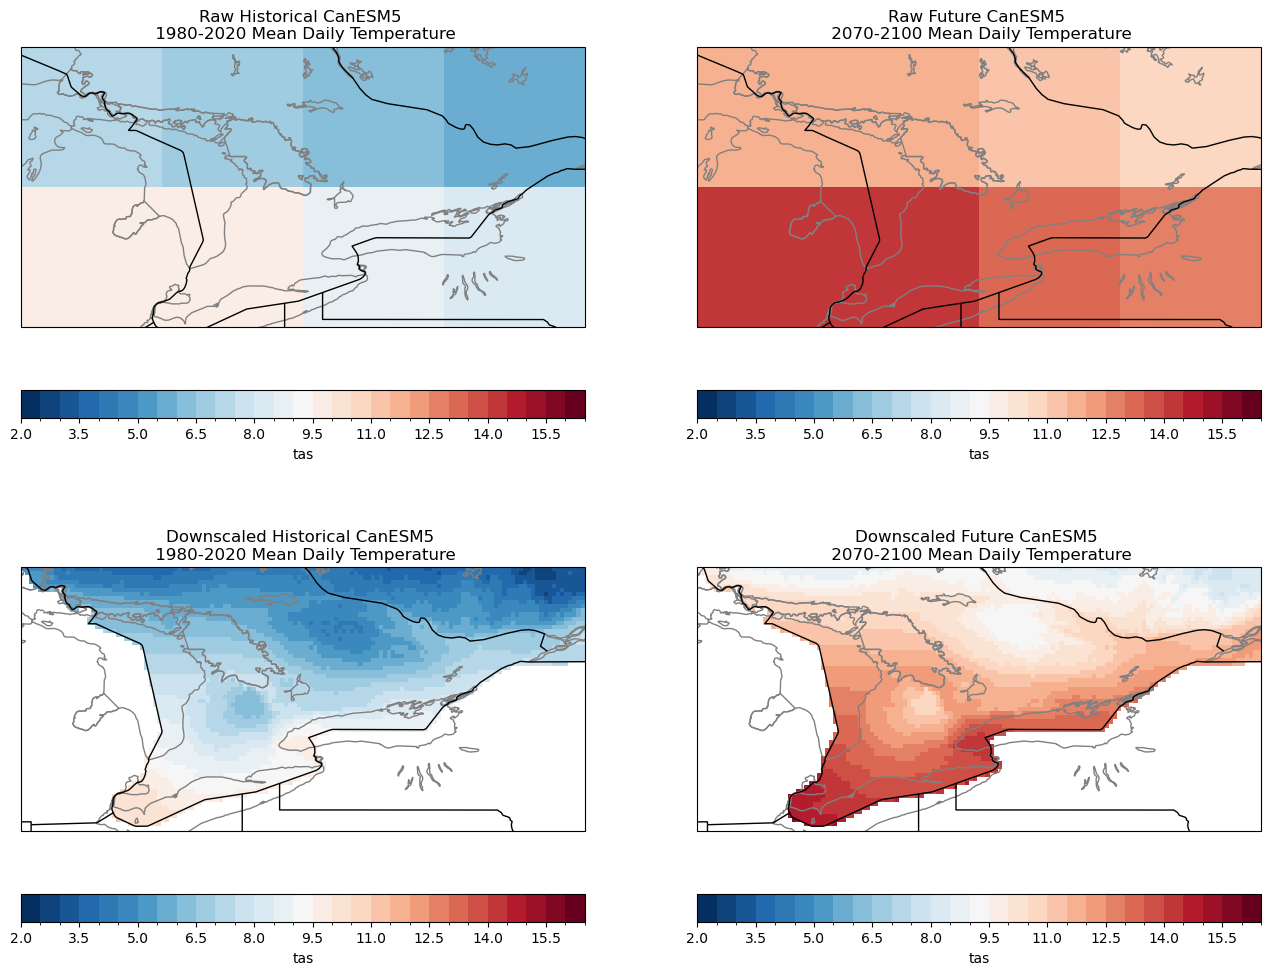

In [318]:
# plot long term means of historical and future simulations, just to compare quickly
cmap = "RdBu_r" 
levels = np.arange(2, 17, 0.5)

#Temperature
fig, axes_2d = plt.subplots(nrows = 2, ncols = 2, subplot_kw = spkws, figsize = (16,12))
axes = axes_2d.flatten()

# Raw Historical
raw_hist.tas.mean('time').plot.pcolormesh(ax = axes[0], 
                                               levels = levels,
                                               cmap = cmap,
                                               cbar_kwargs = dict(orientation='horizontal', extendrect = True),
                                               zorder = 0)
axes[0].set_title("Raw Historical CanESM5 \n 1980-2020 Mean Daily Temperature")

# Raw Future
raw_future.tas.mean('time').plot.pcolormesh(ax = axes[1], 
                                                 levels = levels,
                                                 cmap = cmap,
                                                 cbar_kwargs = dict(orientation='horizontal', extendrect = True),
                                                 zorder = 0)
axes[1].set_title("Raw Future CanESM5 \n 2070-2100 Mean Daily Temperature")

# Downscaled Historical
downscaled_hist.tas.mean('time').plot.pcolormesh(ax = axes[2], 
                                               levels = levels,
                                               cmap = cmap,
                                               cbar_kwargs = dict(orientation='horizontal', extendrect = True),
                                               zorder = 0)
axes[2].set_title("Downscaled Historical CanESM5 \n 1980-2020 Mean Daily Temperature")

# Downscaled Future
downscaled_future.tas.mean('time').plot.pcolormesh(ax = axes[3], 
                                                 levels = levels,
                                                 cmap = cmap,
                                                 cbar_kwargs = dict(orientation='horizontal', extendrect = True),
                                                 zorder = 0)
axes[3].set_title("Downscaled Future CanESM5 \n 2070-2100 Mean Daily Temperature")

for ax in axes:
    ax.coastlines(color = 'grey', zorder = 1)
    ax.add_feature(cfeature.LAKES, edgecolor = 'grey', facecolor = 'none', zorder = 1)
    ax.add_feature(cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='50m', 
                                               facecolor='none', edgecolor='k', linewidth = 1, zorder = 1))
    ax.add_feature(cfeature.BORDERS, edgecolor = 'k', facecolor = 'none', zorder = 2)

plt.show()

There are huge differences between the raw and downscaled model. There are only 8 grid cells covering the spatial domain in the raw model, but downscaling has added more spatial variability and greatly improved the spatial resolution of the model. We can see that temperature are lower in areas with higher elevation, such as Algonquin Provincial Park and southern part of Georgian Bay. Comparing the historical and future periods, both the raw and downscaled model data show very large increase to temperature.

We will then look at precipitation.

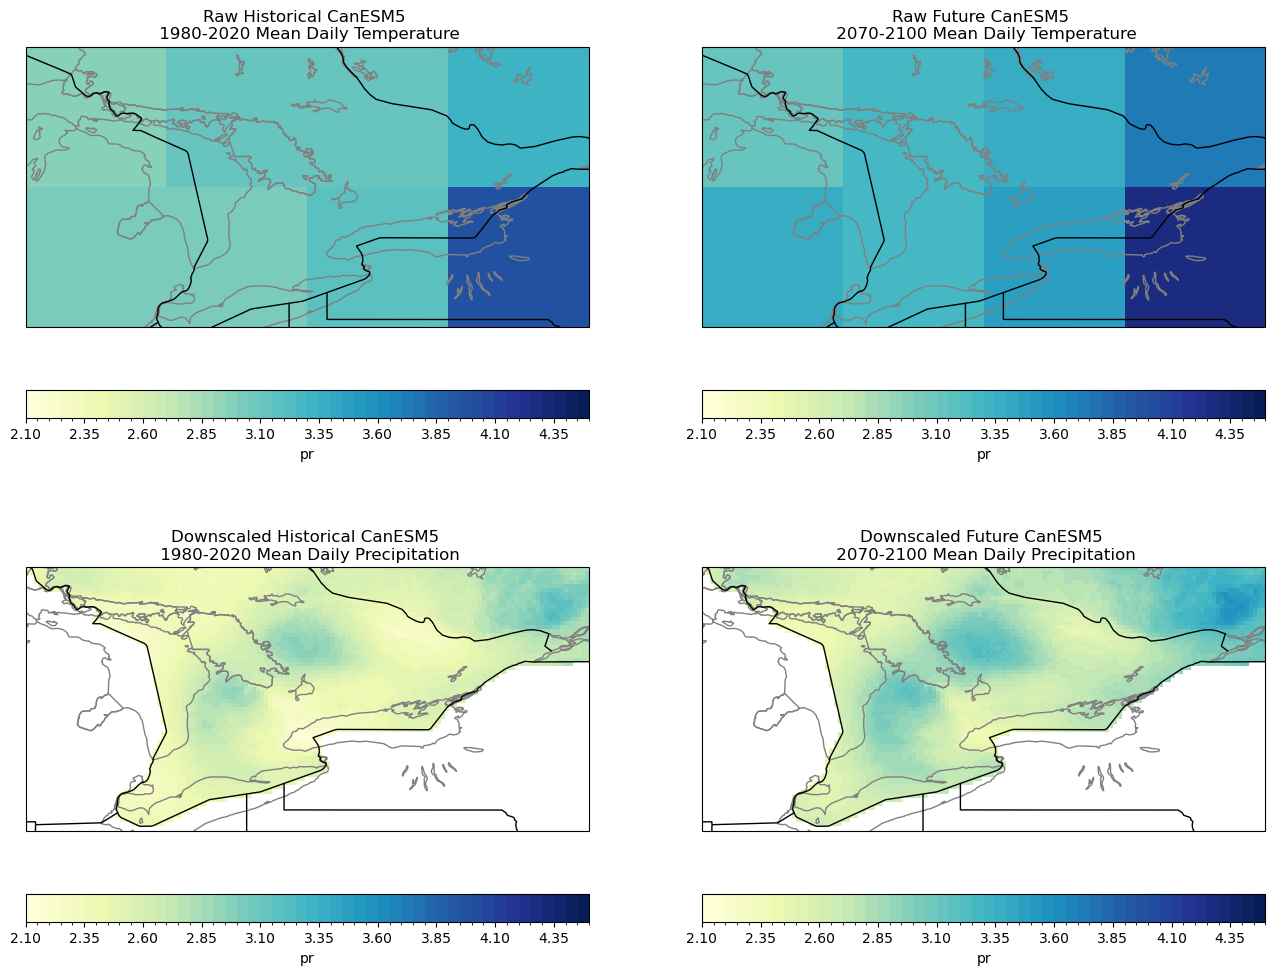

In [323]:
# Precipitation
cmap = "YlGnBu"
levels = np.arange(2.1, 4.55, 0.05)

fig, axes_2d = plt.subplots(nrows = 2, ncols = 2, subplot_kw = spkws, figsize = (16,12))
axes = axes_2d.flatten()

# Raw Historical
raw_hist.pr.mean('time').plot.pcolormesh(ax = axes[0], 
                                               levels = levels,
                                               cmap = cmap,
                                               cbar_kwargs = dict(orientation='horizontal', extendrect = True),
                                               zorder = 0)
axes[0].set_title("Raw Historical CanESM5 \n 1980-2020 Mean Daily Temperature")

# Raw Future
raw_future.pr.mean('time').plot.pcolormesh(ax = axes[1], 
                                                 levels = levels,
                                                 cmap = cmap,
                                                 cbar_kwargs = dict(orientation='horizontal', extendrect = True),
                                                 zorder = 0)
axes[1].set_title("Raw Future CanESM5 \n 2070-2100 Mean Daily Temperature")

# Downscaled Historical
downscaled_hist.pr.mean('time').plot.pcolormesh(ax = axes[2], 
                                               levels = levels,
                                               cmap = cmap,
                                               cbar_kwargs = dict(orientation='horizontal', extendrect = True),
                                               zorder = 0)
axes[2].set_title("Downscaled Historical CanESM5 \n 1980-2020 Mean Daily Precipitation")

# Downscaled Future
downscaled_future.pr.mean('time').plot.pcolormesh(ax = axes[3], 
                                                 levels = levels,
                                                 cmap = cmap,
                                                 cbar_kwargs = dict(orientation='horizontal', extendrect = True),
                                                 zorder = 0)
axes[3].set_title("Downscaled Future CanESM5 \n 2070-2100 Mean Daily Precipitation")

for ax in axes:
    ax.coastlines(color = 'grey', zorder = 1)
    ax.add_feature(cfeature.LAKES, edgecolor = 'grey', facecolor = 'none', zorder = 1)
    ax.add_feature(cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='50m', 
                                               facecolor='none', edgecolor='k', linewidth = 1, zorder = 1))
    ax.add_feature(cfeature.BORDERS, edgecolor = 'k', facecolor = 'none', zorder = 2)

plt.show()

There is a lot going on here. First, the raw model is biased 

## 3.4 Downscaled Projections of our Climate Indicator

After the exploratory analysis, again we will save monthly forcing files to run the B-TIM.

In [ ]:
# Save monthly files to run the B-TIM

# Raw Model
btim(raw_hist.tas, model = "CanESM5raw", type = "hist", var = "tas")
btim(raw_hist.pr, model = "CanESM5raw", type = "hist", var = "pr")

btim(raw_future.tas, model = "CanESM5raw", type = "future", var = "tas")
btim(raw_future.pr, model = "CanESM5raw", type = "future", var = "pr")

# Downscaled Model
btim(downscaled_hist.tas, model = "CanESM5qdm", type = "hist", var = "tas")
btim(downscaled_hist.pr, model = "CanESM5qdm", type = "hist", var = "pr")

btim(downscaled_future.tas, model = "CanESM5qdm", type = "future", var = "tas")
btim(downscaled_future.pr, model = "CanESM5qdm", type = "future", var = "pr")

Then, we will open the B-TIM output

In [325]:
inloc = '/data/kushner_group/lchan/btim/ontario/output/'

#Raw data
snow_ds_raw = xr.open_mfdataset(inloc + 'CanESM5raw' + "/CanESM5raw_forced_swe_*.nc")

snow_ds_raw['SWE'] = snow_ds_raw['snow_depth'] * snow_ds_raw['density'] #SWE = snow depth*density
snow_ds_raw.SWE.attrs['units'] = 'kg/m2' #Change unit
snow_ds_raw

#Downscaled data
snow_ds_downscaled = xr.open_mfdataset(inloc + 'CanESM5BCCAQv2' + "/CanESM5BCCAQv2_forced_swe_*.nc")

snow_ds_downscaled['SWE'] = snow_ds_downscaled['snow_depth'] * snow_ds_downscaled['density'] #SWE = snow depth*density
snow_ds_downscaled.SWE.attrs['units'] = 'kg/m2' #Change unit

In [326]:
# Subset the dataset into historical period and future projections
# Historical
snow_hist_raw = snow_ds_raw.sel(time=slice("1980-08-01", "2020-07-31"))
snow_hist_downscaled = snow_ds_downscaled.sel(time=slice("1980-08-01", "2020-07-31"))

# Future
snow_future_raw = snow_ds_raw.sel(time=slice("2070-08-01", "2100-07-31"))
snow_future_downscaled = snow_ds_downscaled.sel(time=slice("2070-08-01", "2100-07-31"))

### 3.4.1 Snow Cover Duration

Below are some functions to calculate snow cover duration and test if the mean changes are significant. The first function, effective_sample_size, calculate the effective sample size to account for non-independence between serially correlated data points. The second function, get_cont_snow_cover, calculate the snow cover duration for each grid cell in each year, as well as some summary statistics for significance testing. To obtain the longest continuous snow cover period, we use `maximum_consecutive_warm_days` function from `xclim.indicators.atmos`, which calculates the maximum number of consecutive days where the maximum daily temperature exceeds a certain threshold. This function can be used on other climate variables, such as snow depth in this case.

In [332]:
# function for calculating effective sample size, copied section 3.4 from the guidebook
def effective_sample_size(data):
    ntime = len(data.time)
    # times not including the final timestep
    times = data.time.isel(time = slice(0, ntime - 1))
    # data not including the first timestep
    data_lag = data.isel(time = slice(1, ntime))
    # match up time values, otherwise the xr.corr function won't return the correct output
    data_lag = data_lag.assign_coords(time = times)
    
    # calculate correlation
    autocor = xr.corr(data.sel(time = times),
                      data_lag,
                      dim = 'time')
    
    neff = ntime * (1 - autocor) / (1 + autocor)
    
    return neff

In [339]:
def get_cont_snow_cover(data, thresh = '1 cm', freq = 'AS-Aug'):
    
    # Find longest stretch of days where snow depth is greater than or equal to thresh using xclim maximum_consecutive_warm_days function
    with xclim.set_options(data_validation = "log"): #suppress error
        cont_snow_cover = xclim.indicators.atmos.maximum_consecutive_warm_days(data, thresh = thresh, freq = freq)
    
    # get effective sample size for each period, for significance testing later on
    neff = effective_sample_size(cont_snow_cover)
    
    # summary statistics (mean and stdev) - inputs for ttest_ind_from_stats
    cont_snow_cover_mean = cont_snow_cover.mean('time') # Calculate the mean snow covered days across the whole period
    cont_snow_cover_std = cont_snow_cover.std('time')
    
    ds_out = xr.Dataset({'mean': cont_snow_cover_mean, 'std': cont_snow_cover_std, 'neff': neff})
    
    return ds_out

In [331]:
#Calculate the mean continuous snow covered period
#raw model
cont_snow_cover_hist_raw = get_cont_snow_cover(snow_hist_raw.snow_depth)
cont_snow_cover_future_raw = get_cont_snow_cover(snow_future_raw.snow_depth)

# Downscaled model
cont_snow_cover_hist_downscaled = get_cont_snow_cover(snow_hist_downscaled.snow_depth)
cont_snow_cover_future_downscaled = get_cont_snow_cover(snow_future_downscaled.snow_depth)

cont_snow_cover_hist_downscaled # check the results

/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/xclim/core/cfchecks.py:41: UserWarning: Variable does not have a `cell_methods` attribute.
  _check_cell_methods(
/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/xclim/core/cfchecks.py:45: UserWarning: Variable has a non-conforming standard_name: Got `surface_snow_thickness`, expected `['air_temperature']`
  check_valid(vardata, "standard_name", data["standard_name"])
/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/xclim/core/cfchecks.py:41: UserWarning: Variable does not have a `cell_methods` attribute.
  _check_cell_methods(
/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/xclim/core/cfchecks.py:45: UserWarning: Variable has a non-conforming standard_name: Got `surface_snow_thickness`, expected `['air_temperature']`
  check_valid(vardata, "standard_name", data["standard_name"])
/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/xclim/core/cfchecks.py:41: UserWarning: Variable 

<xarray.Dataset>
Dimensions:    (latitude: 64, longitude: 137)
Coordinates:
  * latitude   (latitude) float64 41.62 41.71 41.79 41.87 ... 46.71 46.79 46.87
  * longitude  (longitude) float64 -84.96 -84.88 -84.79 ... -73.79 -73.71 -73.63
Data variables:
    mean       (latitude, longitude) float64 dask.array<chunksize=(64, 137), meta=np.ndarray>
    std        (latitude, longitude) float64 dask.array<chunksize=(64, 137), meta=np.ndarray>
    neff       (latitude, longitude) float64 dask.array<chunksize=(64, 137), meta=np.ndarray>

To examine the projected changes in climate indicators and test the statistical significance, we will use two-sample t-test and the effective sample size correction. However, since we are doing many hypothesis tests for each grid cell simultaneously, and each hypothesis test has a chance of getting false positive results, type I error will be inflated. To correct this issue, we will use the False Discovery Rate correction {cite}`wilks_statistical_2011`.

In [333]:
# function for calculating FDR-corrected significance threshold - copied from section 4.5 from the guidebook
def fdr(p,alpha = 0.1):
    ## p - an array of p-values
    ## alpha - significance p-value threshold
   
    # flatten p
    dims = p.shape
    if len(dims) > 1:
        p = p.flatten()
    sortp = np.sort(p)
    N = len(p)
    slope = np.arange(1,N+1)/N * alpha
    where_p = sortp <= slope
    if np.any(where_p):
        a_fdr = np.max(sortp[where_p])
    else:
        a_fdr = 0
    return a_fdr

In [334]:
# function to do the significance test - copied from section 4.5 from the guidebook
def test_significance(ds_hist, ds_future, alpha = 0.05):
    # do the t-test
    tstats, pvals = stats.ttest_ind_from_stats(ds_hist['mean'], ds_hist['std'], ds_hist['neff'],
                                               ds_future['mean'], ds_future['std'], ds_future['neff'],
                                               equal_var = False)

    # get new threshold using alpha_FDR and get array of 1's where p < alpha_FDR (and 0's otherwise)
    alpha_FDR = fdr(pvals.values, alpha = alpha)
    reject_null = np.where(pvals < alpha_FDR, 1, 0)
    
    return reject_null

In [335]:
# do the significance testing
reject_null_snow_cover_raw = test_significance(cont_snow_cover_hist_raw, cont_snow_cover_future_raw)
reject_null_snow_cover_downscaled = test_significance(cont_snow_cover_hist_downscaled , cont_snow_cover_future_downscaled )

/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Now that everything is done, let's plot the results! We can visualize the results of the significance testing by plotting the mean climate change response, and adding stippling on grid cells for which the null hypothesis is rejected.

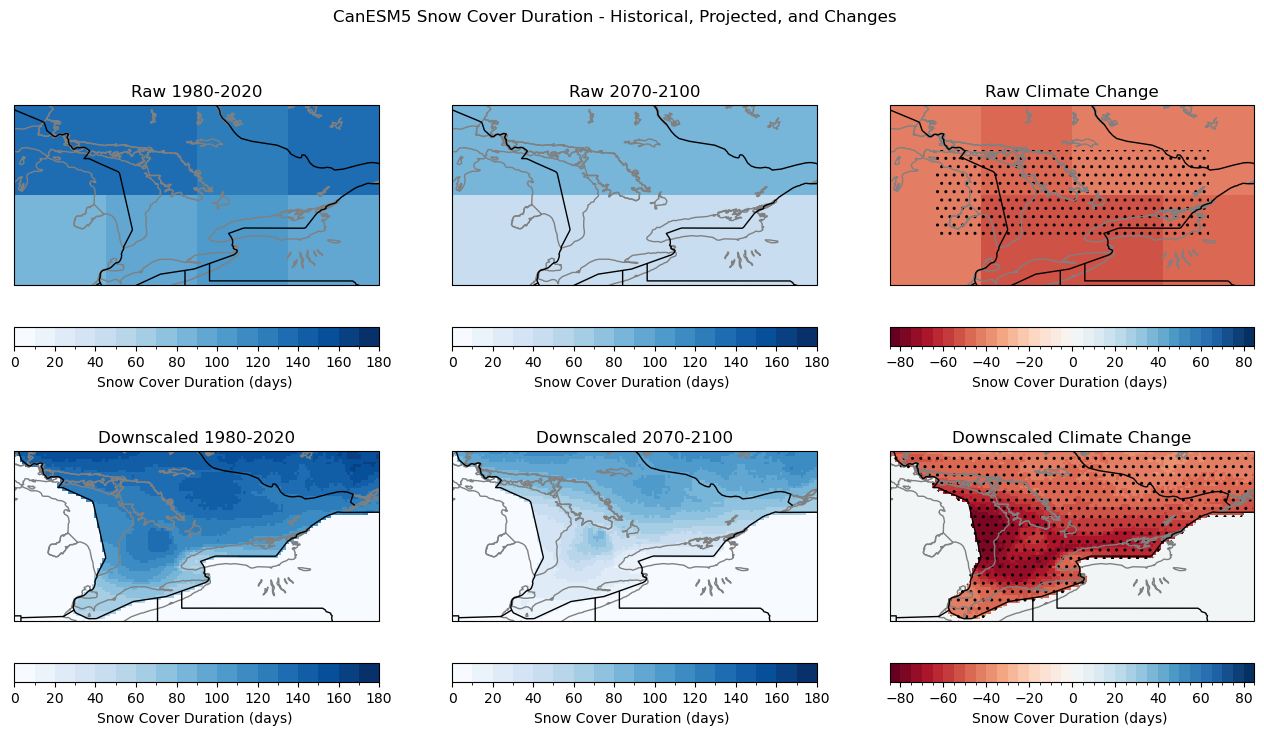

In [336]:
# plot maps for the three cases - historical, future, and the change, for both the raw and downscaled model
# on the delta plot, add stippling to indicate where the changes are statstically significant
levels = np.arange(0, 190, 10)
clevs_delta = np.arange(-85, 90, 5)
cbar_kwargs = dict(orientation = 'horizontal', label = "Snow Cover Duration (days) ")
cmap = "Blues"

fig, axes_2d = plt.subplots(ncols = 3, nrows = 2, figsize = (16, 8), subplot_kw = spkws)
axes = axes_2d.flatten()
fig.suptitle("CanESM5 Snow Cover Duration - Historical, Projected, and Changes")

# Raw Model
## Historical period
p1 = cont_snow_cover_hist_raw['mean'].plot.pcolormesh(ax = axes[0], 
                                                      levels = levels, 
                                                      cmap = cmap,
                                                      cbar_kwargs = cbar_kwargs)
axes[0].set_title("Raw 1980-2020")

## Future simulation
p2 = cont_snow_cover_future_raw['mean'].plot.pcolormesh(ax = axes[1], 
                                                        levels = levels, 
                                                        cmap = cmap, 
                                                        cbar_kwargs = cbar_kwargs)

axes[1].set_title("Raw 2070-2100")

#Difference
delta_snow_cover_raw = cont_snow_cover_future_raw['mean'] - cont_snow_cover_hist_raw['mean']
p3 = delta_snow_cover_raw.plot.pcolormesh(ax = axes[2], 
                                          levels = clevs_delta,
                                          cmap = "RdBu",
                                          cbar_kwargs = cbar_kwargs)

axes[2].set_title("Raw Climate Change")

# add dots (stippling) where reject_null == 1 using plt.contourf
lons = delta_snow_cover_raw.longitude
lats = delta_snow_cover_raw.latitude
axes[2].contourf(lons, lats, reject_null_snow_cover_raw, alpha = 0, levels = [-1, 0, 1], hatches = ["", ".."])


# Downscaled Model
## Historical period
p4 = cont_snow_cover_hist_downscaled['mean'].plot.pcolormesh(ax = axes[3], 
                                                             levels = levels, 
                                                             cmap = cmap,
                                                             cbar_kwargs = cbar_kwargs)
axes[3].set_title("Downscaled 1980-2020")

## Future simulation
p5 = cont_snow_cover_future_downscaled['mean'].plot.pcolormesh(ax = axes[4], 
                                                               levels = levels, 
                                                               cmap = cmap, 
                                                               cbar_kwargs = cbar_kwargs)

axes[4].set_title("Downscaled 2070-2100")

#Difference
delta_snow_cover_downscaled = cont_snow_cover_future_downscaled['mean'] - cont_snow_cover_hist_downscaled['mean']
p6 = delta_snow_cover_downscaled.plot.pcolormesh(ax = axes[5], 
                                                 levels = clevs_delta, 
                                                 cmap = "RdBu",
                                                 cbar_kwargs = cbar_kwargs)
axes[5].set_title("Downscaled Climate Change")

# add dots (stippling) where reject_null == 1 using plt.contourf
lons = delta_snow_cover_downscaled.longitude
lats = delta_snow_cover_downscaled.latitude
axes[5].contourf(lons, lats, reject_null_snow_cover_downscaled, alpha = 0, levels = [-1, 0, 1], hatches = ["", ".."])

for ax in axes:
    ax.coastlines(color = 'grey', zorder = 1)
    ax.add_feature(cfeature.LAKES, edgecolor = 'grey', facecolor = 'none', zorder = 1)
    ax.add_feature(cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='50m', 
                                               facecolor='none', edgecolor='k', linewidth = 1, zorder = 1))
    ax.add_feature(cfeature.BORDERS, edgecolor = 'k', facecolor = 'none', zorder = 2)
    
plt.show()
fig.savefig('map_snow_cover_duration.png', format='png', dpi=1200)

Both the raw and downscaled model data show very large decreases to the snow cover duration. Because projected change is very large, they are statistically significant nearly everywhere in the chosen domain. This is espeically true to area surrounding Lake Ontario, Lake Erie and Lake Huron. One explanation is that there will be less lake-effect snow in the future. It is also important to note that the climate change signal is limited by the original value - if snow cover duration is short in the historical period to begin with, snow cover duration reduction will not be large.

## 3.4.2 Peak SWE

Lastly, we will look at how peak SWE will be affected under climate change. Below is a function that calculate the peak SWE in each year and summary statistics for significance testing.

In [341]:
def get_peak_swe(swe_data, freq = 'AS-Aug'):
    
    # Find peak swe in each snow year (starts from Aug 1 and ends at July 31)
    peak_swe = swe_data.resample(time = freq).max('time')
    
    # Get effective sample size for each period, for significance testing later on
    neff = effective_sample_size(peak_swe)
    
    # Summary statistics (mean and stdev) - inputs for ttest_ind_from_stats
    peak_swe_mean = peak_swe.mean('time') # Calculate the mean snow covered days across the whole period
    peak_swe_std = peak_swe.std('time') #Standard deviation
    
    ds_out = xr.Dataset({'mean': peak_swe_mean, 'std': peak_swe_std, 'neff': neff})
    
    return ds_out

In [342]:
# Calculate the mean peak swe from each period
# Raw model
peak_swe_hist_downscaled = get_peak_swe(snow_hist_downscaled.SWE)
peak_swe_future_downscaled = get_peak_swe(snow_future_downscaled.SWE)

# Downscaled
peak_swe_hist_raw = get_peak_swe(snow_hist_raw.SWE)
peak_swe_future_raw = get_peak_swe(snow_future_raw.SWE)

We again use two-sample t-test with False Discovery Rate correction to examine the projected changes in climate indicators and test the statistical significance.

In [343]:
# Significance testing
reject_null_peak_swe_downscaled = test_significance(peak_swe_hist_downscaled, peak_swe_future_downscaled)
reject_null_peak_swe_raw = test_significance(peak_swe_hist_raw, peak_swe_future_raw)

/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/lchan/anaconda3/envs/UTCDW/lib/python3.9/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


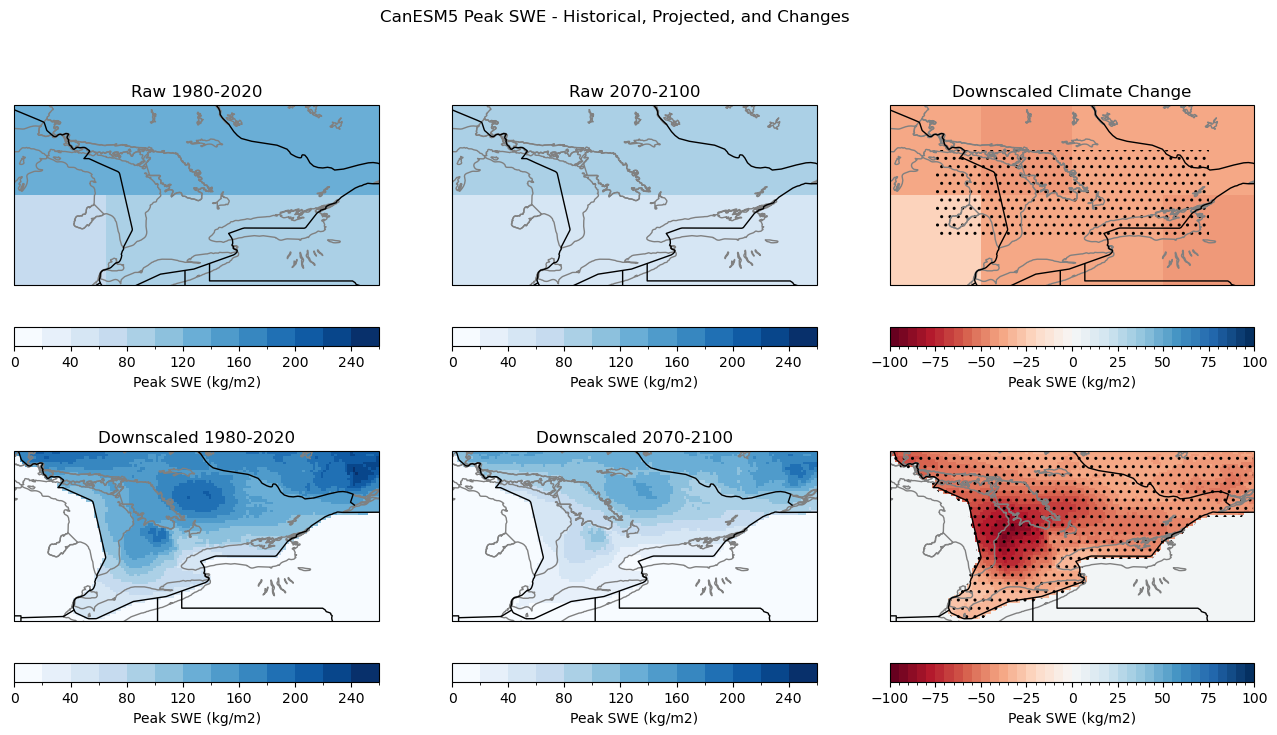

In [344]:
# plot maps for the three cases - historical, future, and the change, for both the raw and downscaled model
# on the delta plot, add stippling to indicate where the changes are statstically significant

cbar_kwargs = dict(orientation = 'horizontal', label = "Peak SWE (kg/m2)")
cmap = "Blues"
levels = levels = np.arange(0, 280, 20)
clevs_delta = np.arange(-100, 105, 5)

fig, axes_2d = plt.subplots(ncols = 3, nrows = 2, figsize = (16, 8), subplot_kw = spkws)
axes = axes_2d.flatten()
fig.suptitle("CanESM5 Peak SWE - Historical, Projected, and Changes")

# Raw model
## Historical period
p1 = peak_swe_hist_raw['mean'].plot.pcolormesh(ax = axes[0], 
                                               levels = levels, 
                                               cmap = cmap,
                                               cbar_kwargs = cbar_kwargs)
axes[0].set_title("Raw 1980-2020")

## Future simulation
p2 = peak_swe_future_raw['mean'].plot.pcolormesh(ax = axes[1], 
                                                 levels = levels, 
                                                 cmap = cmap, 
                                                 cbar_kwargs = cbar_kwargs)

axes[1].set_title("Raw 2070-2100")

##Difference
delta_peak_swe_raw = peak_swe_future_raw['mean'] - peak_swe_hist_raw['mean']
p3 = delta_peak_swe_raw.plot.pcolormesh(ax = axes[2], 
                                        levels = clevs_delta, 
                                        cmap = "RdBu",
                                        cbar_kwargs = cbar_kwargs)
axes[2].set_title("Raw Climate Change")

# add dots (stippling) where reject_null == 1 using plt.contourf
lons = delta_peak_swe_raw.longitude
lats = delta_peak_swe_raw.latitude
axes[2].contourf(lons, lats, reject_null_peak_swe_raw, alpha = 0, levels = [-1, 0, 1], hatches = ["", ".."])

# Downscaled model
## Historical period
p4 = peak_swe_hist_downscaled['mean'].plot.pcolormesh(ax = axes[3], 
                                                      levels = levels, 
                                                      cmap = cmap,
                                                      cbar_kwargs = cbar_kwargs)
axes[3].set_title("Downscaled 1980-2020")


## Future simulation
p5 = peak_swe_future_downscaled['mean'].plot.pcolormesh(ax = axes[4], 
                                                        levels = levels, 
                                                        cmap = cmap, 
                                                        cbar_kwargs = cbar_kwargs)

axes[4].set_title("Downscaled 2070-2100")

##Difference
delta_peak_swe_downscaled = peak_swe_future_downscaled['mean'] - peak_swe_hist_downscaled['mean']
p6 = delta_peak_swe_downscaled.plot.pcolormesh(ax = axes[5], 
                                               levels = clevs_delta, 
                                               cmap = "RdBu",
                                               cbar_kwargs = cbar_kwargs)
axes[2].set_title("Downscaled Climate Change")

# add dots (stippling) where reject_null == 1 using plt.contourf
lons = delta_peak_swe_downscaled.longitude
lats = delta_peak_swe_downscaled.latitude
axes[5].contourf(lons, lats, reject_null_peak_swe_downscaled, alpha = 0, levels = [-1, 0, 1], hatches = ["", ".."])

for ax in axes:
    ax.coastlines(color = 'grey', zorder = 1)
    ax.add_feature(cfeature.LAKES, edgecolor = 'grey', facecolor = 'none', zorder = 1)
    ax.add_feature(cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='50m', 
                                               facecolor='none', edgecolor='k', linewidth = 1, zorder = 1))
    ax.add_feature(cfeature.BORDERS, edgecolor = 'k', facecolor = 'none', zorder = 2)
    
plt.show()

Similar to snow cover duration, smaller-scale spatial features are presen in the downscaled data. Although the climate change signal is not as strong as snow cover duration, it is still significant almost everywhere. The area between Lake Huron and Georgian Bay has the greatest reduction in peak SWE and snow cover period as shown in the previous plot, so this area is at a high risk of water scarcity.

# Summary

A limitation of this study is that so far we only speculate that with less snow, there will be less freshwater available. However, it is important to consider other factors that may affect freshwater, such as how much freshwater resources rely on snowmelt, groundwater and streamflow dynamics. Therefore, further research on the relationship between snowmelt and water resources is needed in order to make conclusion.